In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os
os.chdir('/content/drive/MyDrive/Colab Notebooks/Diego/Paper Interpretability')
print(os.getcwd())

/content/drive/MyDrive/Colab Notebooks/Diego/Paper Interpretability


In [3]:
!pip install optuna
!pip install lime
!pip install tf-keras-vis
!pip install mne

In [4]:
  # ============================================================
# Comparative topoplots by true class y_test
#
# MI:
#   Model: shallowconvnet
#
#   MI_SUBJECTS_TO_EXTRACT:
#       2.5-5:
#           sj43 fold1
#           sj12 fold3
#
#       0-7:
#           sj14 fold4
#           sj12 fold5
#
# General MI figures:
#   - 2x6
#   - upper row: first subject
#   - lower row: second subject
#   - columns: XAI methods
#   - method names only in the first row
#   - one colorbar per figure
#
# STF MI figures:
#   - 0-7:
#       one 4x4 figure per subject
#
#   - 2.5-5:
#       one 2x4 figure
#       upper row: first subject
#       lower row: second subject
#
# TDAH:
#   Model: tgarnet
#   Data: fold_to_extract = 4
#   Attributions/model: fold 5
#
# TDAH figures:
#   - General: 1x6
#   - STF: 1x5
#   - frequency-band names only in the first row
#
# Colorbar:
#   - one colorbar per figure
#   - label: Normalized difference
# ============================================================

import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import mne

from Model_utils.utils import get_segmented_data


# ============================================================
# 0. General configuration
# ============================================================

RESULTS_DIR = "Results"
AUX = "y_test"

MI_MODEL_NAME = "shallowconvnet"
TDAH_MODEL_NAME = "tgarnet"

SAVE_DIR = "Figures"
os.makedirs(SAVE_DIR, exist_ok=True)

# ------------------------------------------------------------
# Font-size configuration
# ------------------------------------------------------------
# caption_fontsize_pt should match the approximate caption size
# used in the manuscript.
#
# figure_fontsize_pt controls titles, labels, colorbar text,
# legend text, and tick labels.
#
# channel_name_fontsize_pt controls only the EEG channel names
# displayed inside the topoplots.

caption_fontsize_pt = 26

figure_fontsize_pt = 0.70 * caption_fontsize_pt
channel_name_fontsize_pt = 0.3 * caption_fontsize_pt
colorbar_tick_fontsize_pt = 0.7 * caption_fontsize_pt

plt.rcParams.update({
    "font.size": figure_fontsize_pt,
    "axes.labelsize": figure_fontsize_pt,
    "xtick.labelsize": figure_fontsize_pt,
    "ytick.labelsize": figure_fontsize_pt,
    "legend.fontsize": figure_fontsize_pt,
    "axes.titlesize": figure_fontsize_pt,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


MI_SUBJECTS_TO_EXTRACT = {
    "2.5-5": {
        43: 1,
        12: 3,
    },
    "0-7": {
        14: 4,
        12: 5,
    },
}

XAI_METHODS = [
    "KernelSHAP",
    "LIME",
    "Occlusion",
    "IntegratedGradients",
    "GradCAM++",
    "STF-KernelSHAP",
]

METHOD_TITLES = {
    "KernelSHAP": "KernelSHAP",
    "LIME": "LIME",
    "Occlusion": "Occlusion",
    "IntegratedGradients": "Integrated Gradients",
    "GradCAM++": "Grad-CAM++",
    "STF-KernelSHAP": "STF-KernelSHAP",
}

MI_CHANNELS = [
    'Fp1', 'Fpz', 'Fp2',
    'AF7', 'AF3', 'AFz', 'AF4', 'AF8',
    'F7', 'F5', 'F3', 'F1', 'Fz', 'F2', 'F4', 'F6', 'F8',
    'FT7', 'FC5', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'FC6', 'FT8',
    'T7', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'T8',
    'TP7', 'CP5', 'CP3', 'CP1', 'CPz', 'CP2', 'CP4', 'CP6', 'TP8',
    'P9', 'P7', 'P5', 'P3', 'P1', 'Pz', 'P2', 'P4', 'P6', 'P8', 'P10',
    'PO7', 'PO3', 'POz', 'PO4', 'PO8',
    'O1', 'Oz', 'O2',
    'Iz'
]

TDAH_CHANNELS = [
    "Fp1", "Fp2",
    "F3", "F4",
    "C3", "C4",
    "P3", "P4",
    "O1", "O2",
    "F7", "F8",
    "T7", "T8",
    "P7", "P8",
    "Fz", "Cz", "Pz",
]


# ============================================================
# 1. File utilities
# ============================================================

def safe_method_name(method_name):
    return (
        method_name
        .replace("+", "plus")
        .replace(" ", "_")
    )


def make_mi_xai_path(
    results_dir,
    window_name,
    subject_id,
    fold,
    model_name,
    method_name,
    aux="y_test",
):
    safe_method = safe_method_name(method_name)

    return os.path.join(
        results_dir,
        f"attributions_{aux}",
        "MI",
        str(window_name),
        f"sj{subject_id}_fold{fold}_{model_name}_{safe_method}.npz",
    )


def make_tdah_xai_path(
    results_dir,
    fold,
    model_name,
    method_name,
    aux="y_test",
    partition_id=None,
):
    safe_method = safe_method_name(method_name)

    output_dir = os.path.join(
        results_dir,
        f"attributions_{aux}",
        "TDAH",
    )

    if partition_id is None:
        filename = (
            f"fold{fold}"
            f"_{model_name}"
            f"_{safe_method}.npz"
        )
    else:
        filename = (
            f"fold{fold}"
            f"_part{partition_id}"
            f"_{model_name}"
            f"_{safe_method}.npz"
        )

    return os.path.join(output_dir, filename)


def load_npz_importance(path):
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"The file does not exist: {path}"
        )

    data = np.load(path)

    if "importance" in data:
        arr = data["importance"]

    elif "relevance_maps" in data:
        arr = data["relevance_maps"]

    else:
        raise KeyError(
            f"The file does not contain 'importance' or 'relevance_maps': {path}. "
            f"Available keys: {list(data.keys())}"
        )

    data.close()

    return np.asarray(arr, dtype=np.float32)


def load_tdah_importance_allow_parts(
    results_dir,
    fold_for_attr,
    model_name,
    method_name,
    aux="y_test",
    n_partitions=7,
):
    full_path = make_tdah_xai_path(
        results_dir=results_dir,
        fold=fold_for_attr,
        model_name=model_name,
        method_name=method_name,
        aux=aux,
        partition_id=None,
    )

    if os.path.exists(full_path):
        return load_npz_importance(full_path)

    parts = []

    for part_id in range(1, n_partitions + 1):

        part_path = make_tdah_xai_path(
            results_dir=results_dir,
            fold=fold_for_attr,
            model_name=model_name,
            method_name=method_name,
            aux=aux,
            partition_id=part_id,
        )

        if os.path.exists(part_path):
            parts.append(
                load_npz_importance(part_path)
            )

    if len(parts) == 0:
        raise FileNotFoundError(
            f"No complete file or partitions were found for "
            f"TDAH fold={fold_for_attr}, model={model_name}, "
            f"method={method_name}."
        )

    return np.concatenate(parts, axis=0)


# ============================================================
# 2. Data loading
# ============================================================

def load_mi_subject_fold(
    base_path_mi,
    window_name,
    subject_id,
    fold,
):
    file_path = os.path.join(
        base_path_mi,
        window_name,
        f"subject_{subject_id}.npz",
    )

    data = np.load(file_path)

    X = data["X"]
    y = data["y"]

    test_idx = data[f"fold_{fold}_test_idx"]

    train_idx = np.setdiff1d(
        np.arange(len(y)),
        test_idx,
    )

    out = {
        "fold": fold,
        "X_train": X[train_idx].astype(np.float32),
        "y_train": y[train_idx],
        "X_test": X[test_idx].astype(np.float32),
        "y_test": y[test_idx],
        "train_idx": train_idx,
        "test_idx": test_idx,
    }

    data.close()

    return out


def load_mi_case(
    window_name,
    subject_id,
    fold,
):
    mi_data = load_mi_subject_fold(
        base_path_mi="Data/MI",
        window_name=window_name,
        subject_id=subject_id,
        fold=fold,
    )

    importance_by_method = {}

    for method_name in XAI_METHODS:

        path = make_mi_xai_path(
            results_dir=RESULTS_DIR,
            window_name=window_name,
            subject_id=subject_id,
            fold=fold,
            model_name=MI_MODEL_NAME,
            method_name=method_name,
            aux=AUX,
        )

        importance_by_method[method_name] = load_npz_importance(path)

    return {
        "window_name": window_name,
        "subject_id": subject_id,
        "fold": fold,
        "data": mi_data,
        "y_test": mi_data["y_test"],
        "importance": importance_by_method,
    }


def load_tdah_fold_data(
    fold_to_extract=4,
):
    with open("Data/TDAH/folds.pkl", "rb") as f:
        folds = pickle.load(f)

    X, y, sbjs, _ = get_segmented_data(
        path_adhd="Data/TDAH/ieee/ADHD_group",
        path_control="Data/TDAH/ieee/Control_group",
    )

    train_subjects, _, test_subjects = folds[fold_to_extract]

    sbjs_array = np.asarray(sbjs)

    train_idx = np.asarray(
        [
            i for i, sbj in enumerate(sbjs)
            if sbj in train_subjects
        ],
        dtype=int,
    )

    test_idx = np.asarray(
        [
            i for i, sbj in enumerate(sbjs)
            if sbj in test_subjects
        ],
        dtype=int,
    )

    return {
        "fold": fold_to_extract,
        "X_train": X[train_idx].astype(np.float32),
        "y_train": y[train_idx],
        "X_test": X[test_idx].astype(np.float32),
        "y_test": y[test_idx],
        "sbjs_train": sbjs_array[train_idx],
        "sbjs_test": sbjs_array[test_idx],
        "train_idx": train_idx,
        "test_idx": test_idx,
    }


# ============================================================
# 3. Base topoplot
# ============================================================

def topoplot_mne_simple(
    data,
    channels,
    montage_name="standard_1020",
    ax=None,
    name_size=None,
    show_sensors=True,
    contours=3,
    cmap="RdBu_r",
    vlim=(-1.0, 1.0),
):
    data = np.asarray(data, dtype=float)

    if name_size is None:
        name_size = channel_name_fontsize_pt

    if len(data) != len(channels):
        raise ValueError(
            f"data has {len(data)} values, "
            f"but channels has {len(channels)} channels."
        )

    info = mne.create_info(
        ch_names=channels,
        sfreq=1,
        ch_types="eeg",
    )

    info.set_montage(
        montage_name,
        on_missing="ignore",
    )

    if ax is None:
        ax = plt.subplot(111)

    n_before = len(ax.texts)

    try:
        im, _ = mne.viz.plot_topomap(
            data,
            info,
            axes=ax,
            show=False,
            names=channels,
            sensors=show_sensors,
            contours=contours,
            cmap=cmap,
            vlim=vlim,
        )

    except TypeError:
        im, _ = mne.viz.plot_topomap(
            data,
            info,
            axes=ax,
            show=False,
            names=channels,
            sensors=show_sensors,
            contours=contours,
            cmap=cmap,
            vmin=vlim[0],
            vmax=vlim[1],
        )

    for txt in ax.texts[n_before:]:
        txt.set_fontsize(name_size)

    ax.set_xlabel("")
    ax.set_ylabel("")

    return im


# ============================================================
# 4. Reduction, mode, and normalization utilities
# ============================================================

def labels_to_1d(y):
    y = np.asarray(y)

    if y.ndim > 1:
        y = np.argmax(y, axis=1)

    return y.astype(int)


def normalize_signed_per_method(x, eps=1e-12):
    x = np.asarray(x, dtype=float)

    max_abs = np.nanmax(np.abs(x))

    if max_abs < eps:
        return np.zeros_like(x)

    return x / (max_abs + eps)


def robust_mode_continuous(
    x,
    axis=None,
    decimals=6,
):
    x = np.asarray(x, dtype=float)

    def _mode_1d(v):
        v = v[~np.isnan(v)]

        if len(v) == 0:
            return np.nan

        v_round = np.round(v, decimals=decimals)

        values, counts = np.unique(
            v_round,
            return_counts=True,
        )

        max_count = np.max(counts)
        modes = values[counts == max_count]

        return np.median(modes)

    if axis is None:
        return _mode_1d(x.ravel())

    if isinstance(axis, int):
        return np.apply_along_axis(
            _mode_1d,
            axis,
            x,
        )

    if isinstance(axis, tuple):
        axis = tuple(
            ax if ax >= 0 else x.ndim + ax
            for ax in axis
        )

        keep_axes = tuple(
            ax for ax in range(x.ndim)
            if ax not in axis
        )

        new_order = keep_axes + axis

        x_perm = np.transpose(
            x,
            new_order,
        )

        keep_shape = x_perm.shape[:len(keep_axes)]
        reduce_shape = x_perm.shape[len(keep_axes):]

        x_flat = x_perm.reshape(
            *keep_shape,
            int(np.prod(reduce_shape)),
        )

        return np.apply_along_axis(
            _mode_1d,
            -1,
            x_flat,
        )

    raise TypeError(
        "axis must be None, int, or tuple[int]. "
        f"Received: {type(axis)}"
    )


def aggregate_array(
    x,
    axis,
    agg="median",
    mode_decimals=6,
):
    if agg == "mean":
        return np.nanmean(
            x,
            axis=axis,
        )

    if agg == "median":
        return np.nanmedian(
            x,
            axis=axis,
        )

    if agg == "mode":
        return robust_mode_continuous(
            x,
            axis=axis,
            decimals=mode_decimals,
        )

    raise ValueError(
        "agg must be 'mean', 'median', or 'mode'. "
        f"Received: {agg}"
    )


# ============================================================
# 5. General reduction for non-STF methods
# ============================================================

def reduce_any_relevance_to_channels(
    relevance_maps,
    mode="signed",
    agg="mean",
):
    rel = np.asarray(relevance_maps, dtype=float)

    if mode == "magnitude":
        rel = np.abs(rel)

    elif mode == "signed":
        pass

    else:
        raise ValueError(
            "mode must be 'signed' or 'magnitude'."
        )

    if rel.ndim < 3:
        raise ValueError(
            f"An array with shape [N, C, ...] was expected. "
            f"Received shape: {rel.shape}"
        )

    axes_to_reduce = tuple(
        range(2, rel.ndim)
    )

    return aggregate_array(
        rel,
        axis=axes_to_reduce,
        agg=agg,
    )


def class_difference_from_NC(
    attr_NC,
    y_test,
    class0=0,
    class1=1,
    class_agg="mean",
    mode_decimals=6,
):
    y = labels_to_1d(y_test)

    attr_NC = np.asarray(attr_NC, dtype=float)

    if attr_NC.shape[0] != len(y):
        raise ValueError(
            "The number of attributions does not match y_test. "
            f"attr_NC.shape[0]={attr_NC.shape[0]}, len(y_test)={len(y)}"
        )

    idx0 = np.where(y == class0)[0]
    idx1 = np.where(y == class1)[0]

    if len(idx0) == 0 or len(idx1) == 0:
        raise ValueError(
            f"There are not enough samples for class0={class0} or class1={class1}. "
            f"n_class0={len(idx0)}, n_class1={len(idx1)}"
        )

    if class_agg == "mean":
        attr_c0 = np.nanmean(
            attr_NC[idx0],
            axis=0,
        )

        attr_c1 = np.nanmean(
            attr_NC[idx1],
            axis=0,
        )

    elif class_agg == "median":
        attr_c0 = np.nanmedian(
            attr_NC[idx0],
            axis=0,
        )

        attr_c1 = np.nanmedian(
            attr_NC[idx1],
            axis=0,
        )

    elif class_agg == "mode":
        attr_c0 = robust_mode_continuous(
            attr_NC[idx0],
            axis=0,
            decimals=mode_decimals,
        )

        attr_c1 = robust_mode_continuous(
            attr_NC[idx1],
            axis=0,
            decimals=mode_decimals,
        )

    else:
        raise ValueError(
            "class_agg must be 'mean', 'median', or 'mode'."
        )

    diff = attr_c1 - attr_c0

    diff_norm = normalize_signed_per_method(diff)

    return {
        "attr_NC": attr_NC,
        "attr_class0": attr_c0,
        "attr_class1": attr_c1,
        "diff": diff,
        "diff_norm": diff_norm,
        "idx_class0": idx0,
        "idx_class1": idx1,
        "class_agg": class_agg,
    }


def class_difference_channels(
    relevance_maps,
    y_test,
    class0=0,
    class1=1,
    relevance_mode="signed",
    channel_agg="mean",
    class_agg="mean",
    mode_decimals=6,
):
    attr_NC = reduce_any_relevance_to_channels(
        relevance_maps=relevance_maps,
        mode=relevance_mode,
        agg=channel_agg,
    )

    return class_difference_from_NC(
        attr_NC=attr_NC,
        y_test=y_test,
        class0=class0,
        class1=class1,
        class_agg=class_agg,
        mode_decimals=mode_decimals,
    )


# ============================================================
# 6. Specific reduction for STF-KernelSHAP
# ============================================================

def reduce_stf_NCSK_to_NCSR(
    relevance_maps,
    freqs_hz,
    freq_bands_hz,
    relevance_mode="signed",
    freq_agg="median",
    mode_decimals=6,
):
    rel = np.asarray(relevance_maps, dtype=float)

    if rel.ndim != 4:
        raise ValueError(
            "STF-KernelSHAP must have shape [N, C, S, K]. "
            f"Received shape: {rel.shape}"
        )

    if relevance_mode == "magnitude":
        rel = np.abs(rel)

    elif relevance_mode == "signed":
        pass

    else:
        raise ValueError(
            "relevance_mode must be 'signed' or 'magnitude'."
        )

    freqs_hz = np.asarray(freqs_hz, dtype=float)

    N, C, S, K = rel.shape

    if len(freqs_hz) != K:
        raise ValueError(
            f"freqs_hz has length {len(freqs_hz)}, "
            f"but relevance_maps has K={K}."
        )

    R = len(freq_bands_hz)

    out = np.zeros(
        (N, C, S, R),
        dtype=float,
    )

    for r, (f0, f1) in enumerate(freq_bands_hz):

        idx = np.where(
            (freqs_hz >= f0) & (freqs_hz <= f1)
        )[0]

        if len(idx) == 0:
            raise ValueError(
                f"The band ({f0}, {f1}) Hz has no available bins."
            )

        out[:, :, :, r] = aggregate_array(
            rel[:, :, :, idx],
            axis=-1,
            agg=freq_agg,
            mode_decimals=mode_decimals,
        )

    return out


def stf_class_difference_CSR(
    relevance_maps,
    y_test,
    freqs_hz,
    freq_bands_hz,
    relevance_mode="signed",
    freq_agg="median",
    class_agg="median",
    mode_decimals=6,
):
    y = labels_to_1d(y_test)

    attr_NCSR = reduce_stf_NCSK_to_NCSR(
        relevance_maps=relevance_maps,
        freqs_hz=freqs_hz,
        freq_bands_hz=freq_bands_hz,
        relevance_mode=relevance_mode,
        freq_agg=freq_agg,
        mode_decimals=mode_decimals,
    )

    if attr_NCSR.shape[0] != len(y):
        raise ValueError(
            "The number of STF attributions does not match y_test. "
            f"attr_NCSR.shape[0]={attr_NCSR.shape[0]}, len(y_test)={len(y)}"
        )

    idx0 = np.where(y == 0)[0]
    idx1 = np.where(y == 1)[0]

    if len(idx0) == 0 or len(idx1) == 0:
        raise ValueError(
            f"There are not enough samples for both classes. "
            f"n_class0={len(idx0)}, n_class1={len(idx1)}"
        )

    if class_agg == "mean":
        attr_c0 = np.nanmean(
            attr_NCSR[idx0],
            axis=0,
        )

        attr_c1 = np.nanmean(
            attr_NCSR[idx1],
            axis=0,
        )

    elif class_agg == "median":
        attr_c0 = np.nanmedian(
            attr_NCSR[idx0],
            axis=0,
        )

        attr_c1 = np.nanmedian(
            attr_NCSR[idx1],
            axis=0,
        )

    elif class_agg == "mode":
        attr_c0 = robust_mode_continuous(
            attr_NCSR[idx0],
            axis=0,
            decimals=mode_decimals,
        )

        attr_c1 = robust_mode_continuous(
            attr_NCSR[idx1],
            axis=0,
            decimals=mode_decimals,
        )

    else:
        raise ValueError(
            "class_agg must be 'mean', 'median', or 'mode'."
        )

    diff = attr_c1 - attr_c0

    max_abs = np.nanmax(
        np.abs(diff)
    )

    if max_abs < 1e-12:
        diff_norm = np.zeros_like(diff)

    else:
        diff_norm = diff / (max_abs + 1e-12)

    return {
        "attr_NCSR": attr_NCSR,
        "attr_class0": attr_c0,
        "attr_class1": attr_c1,
        "diff": diff,
        "diff_norm": diff_norm,
        "idx_class0": idx0,
        "idx_class1": idx1,
        "freq_agg": freq_agg,
        "class_agg": class_agg,
    }


def reduce_stf_to_channels_for_general(
    relevance_maps,
    y_test,
    freqs_hz,
    freq_bands_hz,
    relevance_mode="signed",
    freq_agg="median",
    class_agg="median",
    cell_agg="mean",
    mode_decimals=6,
):
    stf_out = stf_class_difference_CSR(
        relevance_maps=relevance_maps,
        y_test=y_test,
        freqs_hz=freqs_hz,
        freq_bands_hz=freq_bands_hz,
        relevance_mode=relevance_mode,
        freq_agg=freq_agg,
        class_agg=class_agg,
        mode_decimals=mode_decimals,
    )

    diff_CSR = stf_out["diff"]

    if cell_agg == "mean":
        diff_C = np.nanmean(
            diff_CSR,
            axis=(1, 2),
        )

    elif cell_agg == "median":
        diff_C = np.nanmedian(
            diff_CSR,
            axis=(1, 2),
        )

    elif cell_agg == "mode":
        diff_C = aggregate_array(
            diff_CSR,
            axis=(1, 2),
            agg="mode",
            mode_decimals=mode_decimals,
        )

    else:
        raise ValueError(
            "cell_agg must be 'mean', 'median', or 'mode'."
        )

    diff_C_norm = normalize_signed_per_method(diff_C)

    return {
        "diff": diff_C,
        "diff_norm": diff_C_norm,
        "stf_cellwise_output": stf_out,
        "cell_agg": cell_agg,
        "freq_agg": freq_agg,
        "class_agg": class_agg,
    }


# ============================================================
# 7. General figures: 2x6 MI and 1x6 TDAH
# ============================================================

def compute_general_method_output(
    method_name,
    relevance_maps,
    y_test,
    relevance_mode="signed",
    channel_agg="mean",
    class_agg="median",
    stf_freqs_hz=None,
    stf_freq_bands_hz=None,
    stf_freq_agg="median",
    stf_cell_agg="mean",
    mode_decimals=6,
):
    if method_name == "STF-KernelSHAP":

        if stf_freqs_hz is None or stf_freq_bands_hz is None:
            raise ValueError(
                "For STF-KernelSHAP, stf_freqs_hz and stf_freq_bands_hz must be provided."
            )

        return reduce_stf_to_channels_for_general(
            relevance_maps=relevance_maps,
            y_test=y_test,
            freqs_hz=stf_freqs_hz,
            freq_bands_hz=stf_freq_bands_hz,
            relevance_mode=relevance_mode,
            freq_agg=stf_freq_agg,
            class_agg=class_agg,
            cell_agg=stf_cell_agg,
            mode_decimals=mode_decimals,
        )

    return class_difference_channels(
        relevance_maps=relevance_maps,
        y_test=y_test,
        class0=0,
        class1=1,
        relevance_mode=relevance_mode,
        channel_agg=channel_agg,
        class_agg=class_agg,
        mode_decimals=mode_decimals,
    )


def plot_methods_rows_x6_topomap_difference(
    cases,
    channels,
    save_path=None,
    relevance_mode="signed",
    channel_agg="mean",
    class_agg="median",
    stf_freqs_hz=None,
    stf_freq_bands_hz=None,
    stf_freq_agg="median",
    stf_cell_agg="mean",
    mode_decimals=6,
    cmap="RdBu_r",
):
    """
    cases:
        list of dictionaries with:
            - subject_id
            - y_test
            - importance

    Output:
        len(cases) x 6

    For MI:
        len(cases)=2 -> 2x6

    For TDAH:
        len(cases)=1 -> 1x6
    """

    n_rows = len(cases)
    n_cols = len(XAI_METHODS)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(3.1 * n_cols, 3.1 * n_rows),
        squeeze=False,
    )

    last_im = None
    outputs = {}

    for row_idx, case in enumerate(cases):

        case_key = case.get("subject_id", f"row_{row_idx}")
        outputs[case_key] = {}

        for col_idx, method_name in enumerate(XAI_METHODS):

            ax = axes[row_idx, col_idx]

            relevance_maps = case["importance"][method_name]

            out = compute_general_method_output(
                method_name=method_name,
                relevance_maps=relevance_maps,
                y_test=case["y_test"],
                relevance_mode=relevance_mode,
                channel_agg=channel_agg,
                class_agg=class_agg,
                stf_freqs_hz=stf_freqs_hz,
                stf_freq_bands_hz=stf_freq_bands_hz,
                stf_freq_agg=stf_freq_agg,
                stf_cell_agg=stf_cell_agg,
                mode_decimals=mode_decimals,
            )

            outputs[case_key][method_name] = out

            last_im = topoplot_mne_simple(
                data=out["diff_norm"],
                channels=channels,
                ax=ax,
                name_size=channel_name_fontsize_pt,
                show_sensors=True,
                contours=3,
                cmap=cmap,
                vlim=(-1.0, 1.0),
            )

            if row_idx == 0:
                ax.set_title(
                    METHOD_TITLES.get(method_name, method_name),
                    fontsize=figure_fontsize_pt,
                    pad=8,
                )
            else:
                ax.set_title("")

            ax.set_xlabel("")
            ax.set_ylabel("")

    plt.subplots_adjust(
        left=0.025,
        right=0.925,
        top=0.90 if n_rows == 1 else 0.93,
        bottom=0.06,
        wspace=0.06,
        hspace=0.06,
    )

    cbar_ax = fig.add_axes(
        [0.945, 0.18, 0.010, 0.64]
    )

    cbar = fig.colorbar(
        last_im,
        cax=cbar_ax,
        orientation="vertical",
    )

    cbar.set_label(
        "Normalized difference",
        fontsize=figure_fontsize_pt,
    )

    cbar.set_ticks(
        [-1, -0.5, 0, 0.5, 1]
    )

    cbar.ax.tick_params(
        labelsize=colorbar_tick_fontsize_pt
    )

    if save_path is not None:
        os.makedirs(
            os.path.dirname(save_path),
            exist_ok=True,
        )

        fig.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight",
        )

    plt.show()

    return {
        "fig": fig,
        "axes": axes,
        "outputs": outputs,
    }


# ============================================================
# 8. STF figures
# ============================================================

def plot_stf_single_subject_grid(
    relevance_maps,
    y_test,
    channels,
    freqs_hz,
    freq_bands_hz,
    freq_labels,
    time_labels=None,
    save_path=None,
    relevance_mode="signed",
    freq_agg="median",
    class_agg="median",
    mode_decimals=6,
    cmap="RdBu_r",
):
    """
    STF figure for a single subject.

    Example MI 0-7:
        4x4
    """

    out = stf_class_difference_CSR(
        relevance_maps=relevance_maps,
        y_test=y_test,
        freqs_hz=freqs_hz,
        freq_bands_hz=freq_bands_hz,
        relevance_mode=relevance_mode,
        freq_agg=freq_agg,
        class_agg=class_agg,
        mode_decimals=mode_decimals,
    )

    diff_norm = out["diff_norm"]

    n_channels, n_times, n_freqs = diff_norm.shape

    if len(channels) != n_channels:
        raise ValueError(
            f"channels has {len(channels)} channels, but STF has {n_channels}."
        )

    if time_labels is not None and len(time_labels) != n_times:
        raise ValueError(
            f"time_labels has {len(time_labels)} labels, but STF has {n_times}."
        )

    if len(freq_labels) != n_freqs:
        raise ValueError(
            f"freq_labels has {len(freq_labels)} labels, but STF has {n_freqs}."
        )

    fig, axes = plt.subplots(
        n_times,
        n_freqs,
        figsize=(3.1 * n_freqs, 3.0 * n_times),
        squeeze=False,
    )

    last_im = None

    for s in range(n_times):
        for r in range(n_freqs):

            ax = axes[s, r]

            last_im = topoplot_mne_simple(
                data=diff_norm[:, s, r],
                channels=channels,
                ax=ax,
                name_size=channel_name_fontsize_pt,
                show_sensors=True,
                contours=3,
                cmap=cmap,
                vlim=(-1.0, 1.0),
            )

            if s == 0:
                ax.set_title(
                    freq_labels[r],
                    fontsize=figure_fontsize_pt,
                    pad=8,
                )
            else:
                ax.set_title("")

            if time_labels is not None and r == 0:
                ax.set_ylabel(
                    time_labels[s],
                    fontsize=figure_fontsize_pt,
                    rotation=90,
                    labelpad=12,
                )
            else:
                ax.set_ylabel("")

            ax.set_xlabel("")

    plt.subplots_adjust(
        left=0.055,
        right=0.91,
        top=0.93,
        bottom=0.045,
        wspace=0.06,
        hspace=0.06,
    )

    cbar_ax = fig.add_axes(
        [0.935, 0.18, 0.012, 0.64]
    )

    cbar = fig.colorbar(
        last_im,
        cax=cbar_ax,
        orientation="vertical",
    )

    cbar.set_label(
        "Normalized difference",
        fontsize=figure_fontsize_pt,
    )

    cbar.set_ticks(
        [-1, -0.5, 0, 0.5, 1]
    )

    cbar.ax.tick_params(
        labelsize=colorbar_tick_fontsize_pt
    )

    if save_path is not None:
        os.makedirs(
            os.path.dirname(save_path),
            exist_ok=True,
        )

        fig.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight",
        )

    plt.show()

    return {
        "fig": fig,
        "axes": axes,
        "outputs": out,
    }


def plot_stf_two_subjects_vertical_2x4(
    cases,
    channels,
    freqs_hz,
    freq_bands_hz,
    freq_labels,
    save_path=None,
    relevance_mode="signed",
    freq_agg="median",
    class_agg="median",
    mode_decimals=6,
    cmap="RdBu_r",
):
    """
    STF figure for MI 2.5-5.

    Output:
        2x4

    Upper row:
        first subject

    Lower row:
        second subject
    """

    prepared = []
    outputs = {}

    for case in cases:

        subject_id = case["subject_id"]

        out = stf_class_difference_CSR(
            relevance_maps=case["importance"]["STF-KernelSHAP"],
            y_test=case["y_test"],
            freqs_hz=freqs_hz,
            freq_bands_hz=freq_bands_hz,
            relevance_mode=relevance_mode,
            freq_agg=freq_agg,
            class_agg=class_agg,
            mode_decimals=mode_decimals,
        )

        diff_norm = out["diff_norm"]

        if diff_norm.shape[1] != 1:
            raise ValueError(
                "This function expects STF with a single temporal window, "
                f"but received S={diff_norm.shape[1]}."
            )

        prepared.append(
            {
                "subject_id": subject_id,
                "diff_norm": diff_norm,
            }
        )

        outputs[subject_id] = out

    n_rows = len(prepared)
    n_channels, _, n_freqs = prepared[0]["diff_norm"].shape

    if len(channels) != n_channels:
        raise ValueError(
            f"channels has {len(channels)} channels, but STF has {n_channels}."
        )

    if len(freq_labels) != n_freqs:
        raise ValueError(
            f"freq_labels has {len(freq_labels)} labels, but STF has {n_freqs}."
        )

    fig, axes = plt.subplots(
        n_rows,
        n_freqs,
        figsize=(3.1 * n_freqs, 3.0 * n_rows),
        squeeze=False,
    )

    last_im = None

    for row_idx, item in enumerate(prepared):

        for r in range(n_freqs):

            ax = axes[row_idx, r]

            last_im = topoplot_mne_simple(
                data=item["diff_norm"][:, 0, r],
                channels=channels,
                ax=ax,
                name_size=channel_name_fontsize_pt,
                show_sensors=True,
                contours=3,
                cmap=cmap,
                vlim=(-1.0, 1.0),
            )

            if row_idx == 0:
                ax.set_title(
                    freq_labels[r],
                    fontsize=figure_fontsize_pt,
                    pad=8,
                )
            else:
                ax.set_title("")

            ax.set_xlabel("")
            ax.set_ylabel("")

    plt.subplots_adjust(
        left=0.025,
        right=0.91,
        top=0.93,
        bottom=0.06,
        wspace=0.06,
        hspace=0.06,
    )

    cbar_ax = fig.add_axes(
        [0.935, 0.18, 0.012, 0.64]
    )

    cbar = fig.colorbar(
        last_im,
        cax=cbar_ax,
        orientation="vertical",
    )

    cbar.set_label(
        "Normalized difference",
        fontsize=figure_fontsize_pt,
    )

    cbar.set_ticks(
        [-1, -0.5, 0, 0.5, 1]
    )

    cbar.ax.tick_params(
        labelsize=colorbar_tick_fontsize_pt
    )

    if save_path is not None:
        os.makedirs(
            os.path.dirname(save_path),
            exist_ok=True,
        )

        fig.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight",
        )

    plt.show()

    return {
        "fig": fig,
        "axes": axes,
        "outputs": outputs,
    }


# ============================================================
# 9. Frequency bands and frequency axis
# ============================================================

FS = 128
NFFT = 512

FREQS_HZ = np.fft.rfftfreq(
    NFFT,
    d=1.0 / FS,
)

MI_FREQ_BANDS = [
    (4.0, 8.0),
    (8.0, 13.0),
    (13.0, 30.0),
    (30.0, 40.0),
]

MI_FREQ_LABELS = [
    "Theta",
    "Alpha",
    "Beta",
    "Gamma",
]

MI_07_TIME_LABELS = [
    "0–2 s",
    "2–2.5 s",
    "2.5–5 s",
    "5–7 s",
]

TDAH_FREQ_BANDS = [
    (0.5, 4.0),
    (4.0, 8.0),
    (8.0, 13.0),
    (13.0, 30.0),
    (30.0, 40.0),
]

TDAH_FREQ_LABELS = [
    "Delta",
    "Theta",
    "Alpha",
    "Beta",
    "Gamma",
]


# ============================================================
# 10. Run MI
# ============================================================

mi_outputs = {}

for window_name, subjects_folds in MI_SUBJECTS_TO_EXTRACT.items():

    cases = []

    for subject_id, fold in subjects_folds.items():

        case = load_mi_case(
            window_name=window_name,
            subject_id=subject_id,
            fold=fold,
        )

        cases.append(case)

    # --------------------------------------------------------
    # General MI figure: 2x6
    # --------------------------------------------------------

    if window_name == "2.5-5":
        general_save_path = os.path.join(
            SAVE_DIR,
            "MI_2.5-5_XAI.pdf",
        )

    elif window_name == "0-7":
        general_save_path = os.path.join(
            SAVE_DIR,
            "MI_0-7_XAI.pdf",
        )

    else:
        raise ValueError(
            f"MI window is not supported: {window_name}"
        )

    out_general = plot_methods_rows_x6_topomap_difference(
        cases=cases,
        channels=MI_CHANNELS,
        save_path=general_save_path,
        relevance_mode="signed",
        channel_agg="mean",
        class_agg="median",
        stf_freqs_hz=FREQS_HZ,
        stf_freq_bands_hz=MI_FREQ_BANDS,
        stf_freq_agg="median",
        stf_cell_agg="mean",
        mode_decimals=6,
    )

    # --------------------------------------------------------
    # STF MI figure
    # --------------------------------------------------------

    if window_name == "0-7":

        stf_outputs = {}

        for case in cases:

            subject_id = case["subject_id"]

            if subject_id == 12:
                stf_save_path = os.path.join(
                    SAVE_DIR,
                    "MI_0-7_sj12_STF.pdf",
                )

            elif subject_id == 14:
                stf_save_path = os.path.join(
                    SAVE_DIR,
                    "MI_0-7_sj14_STF.pdf",
                )

            else:
                stf_save_path = os.path.join(
                    SAVE_DIR,
                    f"MI_0-7_sj{subject_id}_STF.pdf",
                )

            out_stf = plot_stf_single_subject_grid(
                relevance_maps=case["importance"]["STF-KernelSHAP"],
                y_test=case["y_test"],
                channels=MI_CHANNELS,
                freqs_hz=FREQS_HZ,
                freq_bands_hz=MI_FREQ_BANDS,
                freq_labels=MI_FREQ_LABELS,
                time_labels=MI_07_TIME_LABELS,
                save_path=stf_save_path,
                relevance_mode="signed",
                freq_agg="median",
                class_agg="median",
                mode_decimals=6,
            )

            stf_outputs[subject_id] = out_stf

    elif window_name == "2.5-5":

        stf_outputs = plot_stf_two_subjects_vertical_2x4(
            cases=cases,
            channels=MI_CHANNELS,
            freqs_hz=FREQS_HZ,
            freq_bands_hz=MI_FREQ_BANDS,
            freq_labels=MI_FREQ_LABELS,
            save_path=os.path.join(
                SAVE_DIR,
                "MI_2.5-5_STF.pdf",
            ),
            relevance_mode="signed",
            freq_agg="median",
            class_agg="median",
            mode_decimals=6,
        )

    else:
        raise ValueError(
            f"MI window is not supported: {window_name}"
        )

    mi_outputs[window_name] = {
        "cases": cases,
        "general": out_general,
        "stf": stf_outputs,
    }


# ============================================================
# 11. Run TDAH
# ============================================================

tdah_data = load_tdah_fold_data(
    fold_to_extract=4,
)

importance_tdah = {}

for method_name in XAI_METHODS:

    importance_tdah[method_name] = load_tdah_importance_allow_parts(
        results_dir=RESULTS_DIR,
        fold_for_attr=5,
        model_name=TDAH_MODEL_NAME,
        method_name=method_name,
        aux=AUX,
        n_partitions=7,
    )

tdah_case = {
    "subject_id": "TDAH",
    "fold": 5,
    "y_test": tdah_data["y_test"],
    "importance": importance_tdah,
}

# ------------------------------------------------------------
# General TDAH figure: 1x6
# ------------------------------------------------------------

out_tdah_general = plot_methods_rows_x6_topomap_difference(
    cases=[tdah_case],
    channels=TDAH_CHANNELS,
    save_path=os.path.join(
        SAVE_DIR,
        "TDAH_XAI.pdf",
    ),
    relevance_mode="signed",
    channel_agg="mean",
    class_agg="median",
    stf_freqs_hz=FREQS_HZ,
    stf_freq_bands_hz=TDAH_FREQ_BANDS,
    stf_freq_agg="median",
    stf_cell_agg="mean",
    mode_decimals=6,
)

# ------------------------------------------------------------
# STF TDAH figure: 1x5
# ------------------------------------------------------------

out_tdah_stf = plot_stf_single_subject_grid(
    relevance_maps=importance_tdah["STF-KernelSHAP"],
    y_test=tdah_data["y_test"],
    channels=TDAH_CHANNELS,
    freqs_hz=FREQS_HZ,
    freq_bands_hz=TDAH_FREQ_BANDS,
    freq_labels=TDAH_FREQ_LABELS,
    time_labels=None,
    save_path=os.path.join(
        SAVE_DIR,
        "TDAH_STF.pdf",
    ),
    relevance_mode="signed",
    freq_agg="median",
    class_agg="median",
    mode_decimals=6,
)

Output hidden; open in https://colab.research.google.com to view.

Building MI data
[OK] MI | window=2.5-5 | subject=43 | fold=1 | X_test=(40, 64, 320)
[OK] MI | window=2.5-5 | subject=12 | fold=3 | X_test=(35, 64, 320)
[OK] MI | window=0-7 | subject=14 | fold=4 | X_test=(40, 64, 896)
[OK] MI | window=0-7 | subject=12 | fold=5 | X_test=(34, 64, 896)
Building TDAH data
[OK] TDAH | data_fold=4 | X_test=(1722, 19, 512)
Computing MI score curves


Faithfulness MI selected:   0%|          | 0/24 [00:00<?, ?it/s]

Computing TDAH score curves


Faithfulness TDAH selected:   0%|          | 0/6 [00:00<?, ?it/s]

[OK] Per-sample score CSV saved
Results/faithfulness_selected_relevance/faithfulness_selected_relevance_score_per_sample.csv
Shape: (123486, 14)
[OK] Plot-ready score CSV saved
Results/faithfulness_selected_relevance/faithfulness_selected_relevance_score_plot_ready.csv
Shape: (330, 15)


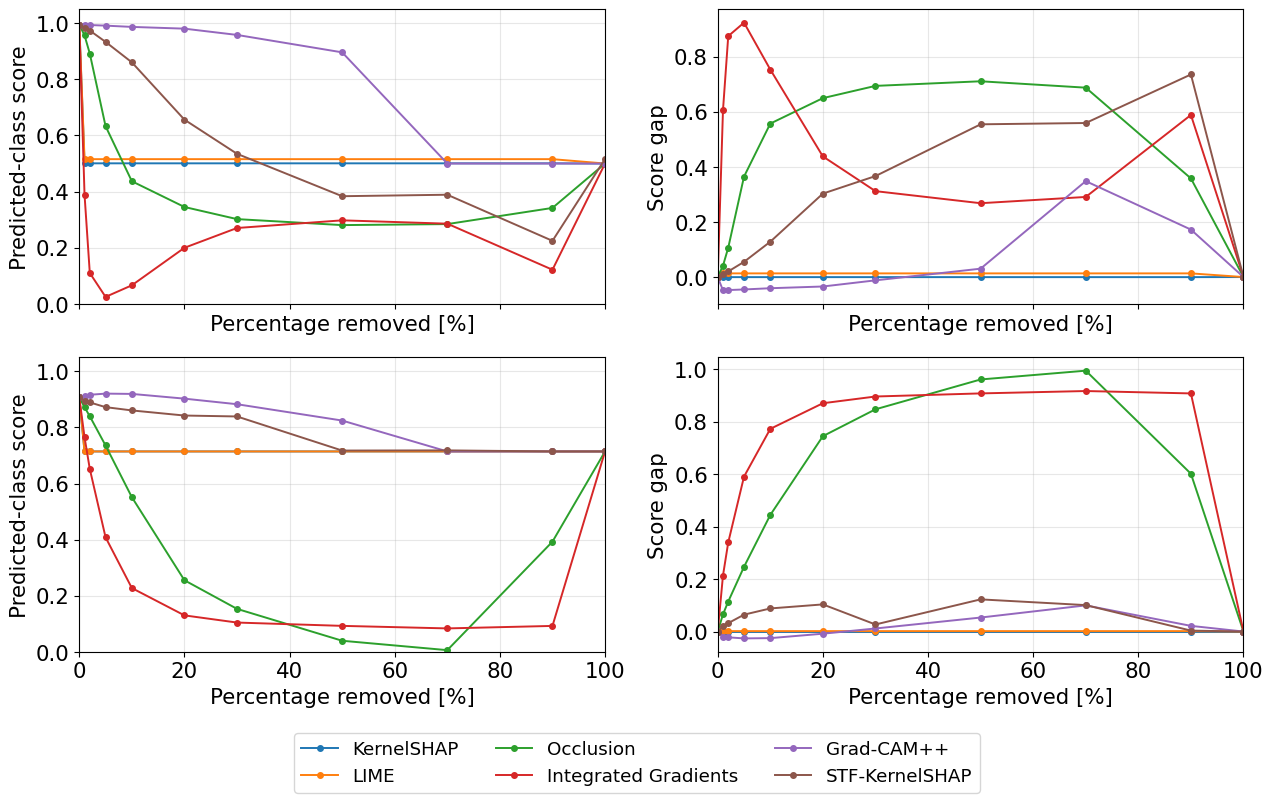

[OK] Figure saved at: Figures/DR_2.5-5.pdf


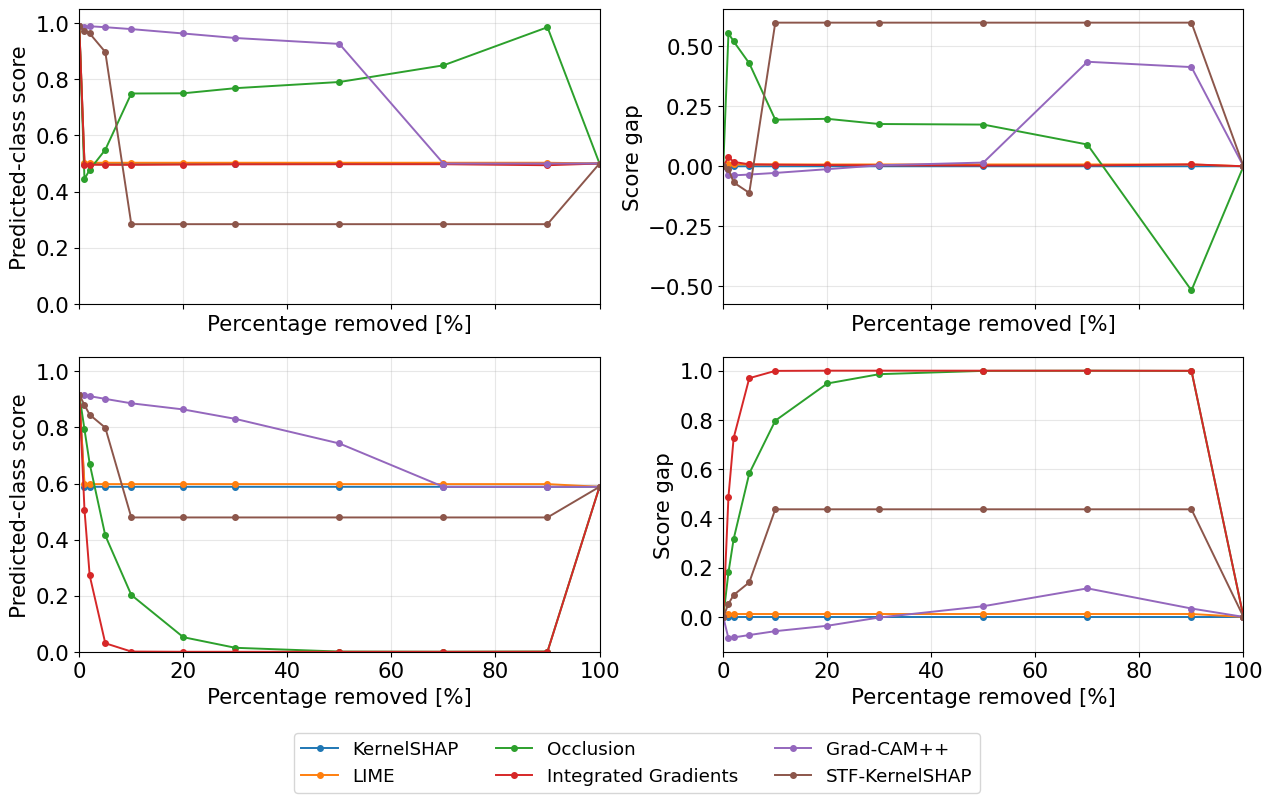

[OK] Figure saved at: Figures/DR_0_7.pdf


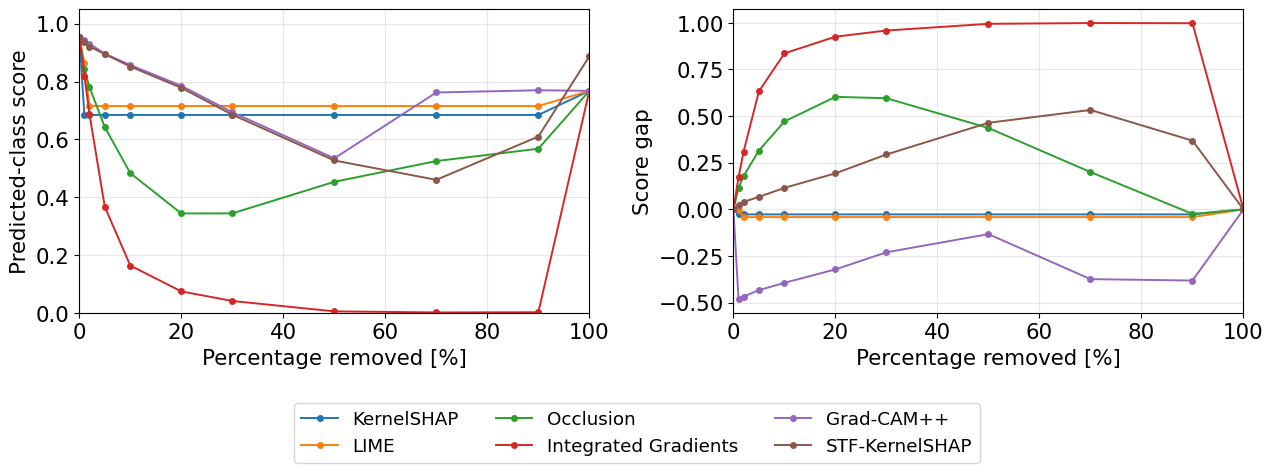

[OK] Figure saved at: Figures/DR_TDAH.pdf


In [5]:
# ============================================================
# Faithfulness curves from relevance files
#
# MI:
#   Model: shallowconvnet
#   Window 2.5-5:
#       subject 43 | fold 1
#       subject 12 | fold 3
#   Window 0-7:
#       subject 14 | fold 4
#       subject 12 | fold 5
#
# TDAH:
#   Model: tgarnet
#   Data: fold_to_extract = 4
#   Model/attributions: fold 5
#
# Outputs:
#   1) Minimal CSV:
#      Results/faithfulness_selected_relevance/faithfulness_selected_relevance.csv
#
#   2) MI figures:
#      Figures/DR_2.5-5.pdf
#      Figures/DR_0_7.pdf
#
#   3) TDAH figure:
#      Figures/DR_TDAH.pdf
# ============================================================

import os
import gc
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from sklearn.metrics import accuracy_score

from Model_utils.xai_runner import (
    predict_proba,
    make_xai_filename,
    make_tdah_xai_filename,
    load_mi_model_and_predict,
    load_tdah_model_and_predict,
)

from Model_utils.utils import get_segmented_data

from Model_utils.stf_kernelshap import (
    SegmentFFTConfig,
    SegmentFFTTransform,
    STFCellPartition,
    prepare_eeg_sample_for_transform,
    restore_batch_shape_from_ct,
)


# ============================================================
# 0. Main configuration
# ============================================================

RESULTS_DIR = "Results"

OUTPUT_DIR = os.path.join(
    RESULTS_DIR,
    "faithfulness_selected_relevance",
)

FIGURES_DIR = "Figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

AUX = "y_pred"

MI_MODEL_NAME = "shallowconvnet"
TDAH_MODEL_NAME = "tgarnet"

MI_SUBJECTS_TO_EXTRACT = {
    "2.5-5": {
        43: 1,
        12: 3,
    },
    "0-7": {
        14: 4,
        12: 5,
    },
}

TDAH_DATA_FOLD = 4
TDAH_MODEL_ATTR_FOLD = 5

XAI_METHODS = (
    "KernelSHAP",
    "LIME",
    "Occlusion",
    "IntegratedGradients",
    "GradCAM++",
    "STF-KernelSHAP",
)

PERCENTAGES = np.array(
    [0, 1, 2, 5, 10, 20, 30, 50, 70, 90, 100],
    dtype=float,
)

# ------------------------------------------------------------
# Font-size configuration
# ------------------------------------------------------------
# caption_fontsize_pt should match the approximate caption size
# used in the manuscript.
#
# figure_fontsize_pt controls axis labels and tick labels.
# legend_fontsize_pt controls only the legend text.

caption_fontsize_pt = 22

figure_fontsize_pt = 0.70 * caption_fontsize_pt
legend_fontsize_pt = 0.60 * caption_fontsize_pt

plt.rcParams.update({
    "font.size": figure_fontsize_pt,
    "axes.labelsize": figure_fontsize_pt,
    "xtick.labelsize": figure_fontsize_pt,
    "ytick.labelsize": figure_fontsize_pt,
    "legend.fontsize": legend_fontsize_pt,
    "axes.titlesize": figure_fontsize_pt,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


# ============================================================
# 1. General utilities
# ============================================================

def safe_method_name(method_name):
    return (
        method_name
        .replace("+", "plus")
        .replace(" ", "_")
    )


def labels_1d(y):
    """
    Converts labels to a 1D vector.
    """

    y = np.asarray(y)

    if y.ndim == 1:
        return y.astype(int)

    if y.ndim == 2:

        if y.shape[1] == 1:
            return y[:, 0].astype(int)

        return np.argmax(y, axis=1).astype(int)

    raise ValueError(
        f"Could not convert y to 1D labels. Received shape: {y.shape}"
    )


def compute_accuracy_from_probs(y_true, y_prob):
    y_true = labels_1d(y_true)
    y_prob = np.asarray(y_prob)

    if y_prob.ndim == 1:
        y_pred = (y_prob >= 0.5).astype(int)
    else:
        y_pred = np.argmax(y_prob, axis=1).astype(int)

    return accuracy_score(
        y_true,
        y_pred,
    )


def load_saved_importance(npz_path):
    """
    Loads a saved relevance matrix.

    Supported keys:
        importance
        relevance_maps
    """

    if not os.path.exists(npz_path):
        raise FileNotFoundError(
            f"The file does not exist:\n{npz_path}"
        )

    data = np.load(
        npz_path,
        allow_pickle=True,
    )

    if "importance" in data.files:
        importance = data["importance"].astype(np.float32)

    elif "relevance_maps" in data.files:
        importance = data["relevance_maps"].astype(np.float32)

    else:
        raise KeyError(
            f"The file does not contain 'importance' or 'relevance_maps'. "
            f"Available keys: {data.files}"
        )

    data.close()

    return importance


def load_tdah_importance_allow_parts(
    results_dir,
    fold,
    model_name,
    method_name,
    aux="y_pred",
    n_partitions=7,
):
    """
    Loads TDAH relevances.

    First, it tries the complete file:
        fold5_tgarnet_Method.npz

    If it does not exist, it tries to concatenate partitions:
        fold5_part1_tgarnet_Method.npz
        ...
        fold5_part7_tgarnet_Method.npz
    """

    full_path = make_tdah_xai_filename(
        results_dir=results_dir,
        fold=fold,
        model_name=model_name,
        method_name=method_name,
        partition_id=None,
        aux=aux,
    )

    if os.path.exists(full_path):
        return load_saved_importance(full_path)

    parts = []

    for part_id in range(1, n_partitions + 1):

        part_path = make_tdah_xai_filename(
            results_dir=results_dir,
            fold=fold,
            model_name=model_name,
            method_name=method_name,
            partition_id=part_id,
            aux=aux,
        )

        if os.path.exists(part_path):
            parts.append(
                load_saved_importance(part_path)
            )

    if len(parts) == 0:
        raise FileNotFoundError(
            f"No complete file or partitions were found for:\n"
            f"fold={fold}, model={model_name}, method={method_name}, aux={aux}"
        )

    return np.concatenate(
        parts,
        axis=0,
    )


def get_stf_time_segments(window_name=None):
    """
    Temporal segments used by STF-KernelSHAP.

    MI 0-7:
        4 segments.

    MI 2.5-5 and TDAH:
        None, which means the whole window is used.
    """

    if window_name == "0-7":
        return [
            (0.0, 2.0),
            (2.0, 2.5),
            (2.5, 5.0),
            (5.0, 7.0),
        ]

    return None


def select_indices_by_percentage_with_ties(
    scores,
    percentage,
    order="most_relevant",
    decimals=8,
):
    """
    Selects indices while preserving ties.

    MoRF:
        order="most_relevant"

    LeRF:
        order="least_relevant"
    """

    scores = np.asarray(
        scores,
        dtype=float,
    )

    total_items = len(scores)

    k = int(
        np.round(
            (percentage / 100.0) * total_items
        )
    )

    k = min(
        max(k, 0),
        total_items,
    )

    if k == 0:
        return np.array(
            [],
            dtype=int,
        )

    scores_round = np.round(
        scores,
        decimals=decimals,
    )

    if order == "most_relevant":
        sorted_idx = np.argsort(scores_round)[::-1]

    elif order == "least_relevant":
        sorted_idx = np.argsort(scores_round)

    else:
        raise ValueError(
            "order must be 'most_relevant' or 'least_relevant'."
        )

    boundary_idx = sorted_idx[k - 1]
    boundary_score = scores_round[boundary_idx]

    if order == "most_relevant":
        selected_idx = np.where(
            scores_round >= boundary_score
        )[0]

    else:
        selected_idx = np.where(
            scores_round <= boundary_score
        )[0]

    return selected_idx.astype(int)


# ============================================================
# 2. MI data construction
# ============================================================

def build_mi_data_from_npz(
    base_path_mi,
    mi_subjects_to_extract,
):
    """
    Builds mi_data from:

        Data/MI/<window_name>/subject_<subject_id>.npz
    """

    mi_data = {}

    for window_name, subjects_folds in mi_subjects_to_extract.items():

        mi_data[window_name] = {}

        for subject_id, fold in subjects_folds.items():

            file_path = os.path.join(
                base_path_mi,
                str(window_name),
                f"subject_{subject_id}.npz",
            )

            if not os.path.exists(file_path):
                raise FileNotFoundError(
                    f"The MI file does not exist:\n{file_path}"
                )

            data = np.load(file_path)

            X = data["X"].astype(np.float32)
            y = data["y"]

            test_key = f"fold_{fold}_test_idx"
            train_key = f"fold_{fold}_train_idx"

            if test_key not in data.files:
                raise KeyError(
                    f"The key '{test_key}' does not exist in:\n{file_path}"
                )

            test_idx = data[test_key].astype(int)

            if train_key in data.files:
                train_idx = data[train_key].astype(int)
            else:
                train_idx = np.setdiff1d(
                    np.arange(X.shape[0]),
                    test_idx,
                )

            mi_data[window_name][subject_id] = {
                "fold": fold,
                "X_train": X[train_idx].astype(np.float32),
                "y_train": y[train_idx],
                "X_test": X[test_idx].astype(np.float32),
                "y_test": y[test_idx],
                "train_idx": train_idx,
                "test_idx": test_idx,
            }

            print(
                f"[OK] MI | window={window_name} | "
                f"subject={subject_id} | fold={fold} | "
                f"X_test={mi_data[window_name][subject_id]['X_test'].shape}"
            )

            data.close()

    return mi_data


# ============================================================
# 3. TDAH data construction
# ============================================================

def build_tdah_data_from_segmented(
    fold_to_extract=4,
    folds_path="Data/TDAH/folds.pkl",
    path_adhd="Data/TDAH/ieee/ADHD_group",
    path_control="Data/TDAH/ieee/Control_group",
):
    """
    Builds TDAH using the previous logic:

        folds.pkl
        get_segmented_data(...)
        train_subjects / test_subjects

    fold_to_extract=4:
        used to extract X_test/y_test.
    """

    if not os.path.exists(folds_path):
        raise FileNotFoundError(
            f"folds_path does not exist:\n{folds_path}"
        )

    with open(folds_path, "rb") as f:
        folds = pickle.load(f)

    X, y, sbjs, _ = get_segmented_data(
        path_adhd=path_adhd,
        path_control=path_control,
    )

    X = np.asarray(X).astype(np.float32)
    y = np.asarray(y)
    sbjs_array = np.asarray(sbjs)

    train_subjects, _, test_subjects = folds[fold_to_extract]

    train_idx = np.asarray(
        [
            i for i, sbj in enumerate(sbjs)
            if sbj in train_subjects
        ],
        dtype=int,
    )

    test_idx = np.asarray(
        [
            i for i, sbj in enumerate(sbjs)
            if sbj in test_subjects
        ],
        dtype=int,
    )

    tdah_data = {
        "fold": fold_to_extract,
        "X_train": X[train_idx].astype(np.float32),
        "y_train": y[train_idx],
        "X_test": X[test_idx].astype(np.float32),
        "y_test": y[test_idx],
        "sbjs_train": sbjs_array[train_idx],
        "sbjs_test": sbjs_array[test_idx],
        "train_idx": train_idx,
        "test_idx": test_idx,
    }

    print(
        f"[OK] TDAH | data_fold={fold_to_extract} | "
        f"X_test={tdah_data['X_test'].shape}"
    )

    return tdah_data


# ============================================================
# 4. Temporal perturbation: importance [N, C, T]
# ============================================================

def squeeze_last_channel_if_needed(A):
    A = np.asarray(A)

    if A.ndim == 4 and A.shape[-1] == 1:
        return A[..., 0]

    return A


def prepare_X_and_importance_temporal(
    X,
    importance,
):
    """
    Converts X and importance to the internal shape [N, C, T].
    """

    X = np.asarray(
        X,
        dtype=np.float32,
    )

    importance = np.asarray(
        importance,
        dtype=np.float32,
    )

    original_ndim = X.ndim

    if X.ndim == 4 and X.shape[-1] == 1:
        X_work = X[..., 0]

    elif X.ndim == 3:
        X_work = X

    else:
        raise ValueError(
            f"Unsupported X shape: {X.shape}"
        )

    importance_work = squeeze_last_channel_if_needed(
        importance
    )

    if importance_work.shape != X_work.shape:
        raise ValueError(
            "Temporal importance does not match X.\n"
            f"X_work: {X_work.shape}\n"
            f"importance: {importance_work.shape}"
        )

    return X_work, importance_work, original_ndim


def restore_X_shape(
    X_work,
    original_ndim,
):
    if original_ndim == 4:
        return X_work[..., None].astype(np.float32)

    return X_work.astype(np.float32)


def perturb_batch_temporal(
    X,
    importance,
    percentage,
    order="most_relevant",
    baseline_value=0.0,
    use_abs=True,
):
    """
    Temporal perturbation for methods with importance [N, C, T].
    """

    X_work, importance_work, original_ndim = prepare_X_and_importance_temporal(
        X=X,
        importance=importance,
    )

    N, C, T = X_work.shape
    F = C * T

    k = int(
        np.round(
            (percentage / 100.0) * F
        )
    )

    k = min(
        max(k, 0),
        F,
    )

    if k == 0:
        return X.copy().astype(np.float32)

    score = np.abs(importance_work) if use_abs else importance_work

    X_flat = X_work.reshape(N, F)
    score_flat = score.reshape(N, F)

    X_pert_flat = X_flat.copy()

    for i in range(N):

        idx = select_indices_by_percentage_with_ties(
            scores=score_flat[i],
            percentage=percentage,
            order=order,
            decimals=8,
        )

        X_pert_flat[i, idx] = baseline_value

    X_pert = X_pert_flat.reshape(N, C, T)

    return restore_X_shape(
        X_work=X_pert,
        original_ndim=original_ndim,
    )


# ============================================================
# 5. STF-KernelSHAP perturbation: importance [N, C, S, K]
# ============================================================

def build_stf_blocks_from_transform(
    transform,
    time_segments_sec,
    freq_bands_hz,
):
    """
    Reconstructs STF cells:
        temporal segment + frequency band.
    """

    partition = STFCellPartition(
        time_intervals_sec=time_segments_sec,
        freq_bands_hz=freq_bands_hz,
        time_labels=None,
        freq_labels=None,
    )

    cells = partition.build_cells(
        segment_info=transform.get_time_segments_info(),
        freqs_hz=transform.get_frequency_axis_hz(),
    )

    return cells


def compute_stf_block_scores(
    importance_stf,
    cells,
    use_abs=True,
):
    """
    Computes one score per block:
        channel + segment + frequency band.
    """

    importance_stf = np.asarray(
        importance_stf,
        dtype=np.float32,
    )

    if importance_stf.ndim != 3:
        raise ValueError(
            "importance_stf must have shape [C, S, K]. "
            f"Received shape: {importance_stf.shape}"
        )

    C, S, K = importance_stf.shape

    block_scores = []
    block_index = []

    for c in range(C):

        for cell in cells:

            s = cell.segment_idx
            f0 = cell.freq_idx_start
            f1 = cell.freq_idx_end

            if s < 0 or s >= S:
                raise ValueError(
                    f"segment_idx={s} is out of range for S={S}"
                )

            if f0 < 0 or f1 > K or f0 >= f1:
                raise ValueError(
                    f"Invalid frequency range: f0={f0}, f1={f1}, K={K}"
                )

            block_values = importance_stf[
                c,
                s,
                f0:f1,
            ]

            if use_abs:
                score = np.median(
                    np.abs(block_values)
                )
            else:
                score = np.median(
                    block_values
                )

            block_scores.append(float(score))
            block_index.append((c, cell))

    return (
        np.asarray(block_scores, dtype=np.float32),
        block_index,
    )


def perturb_one_sample_stf(
    x,
    importance_stf,
    percentage,
    fs=128,
    time_segments_sec=None,
    nfft=512,
    baseline_tf=None,
    order="most_relevant",
    use_abs=True,
):
    """
    Perturbs one sample using STF-KernelSHAP.

    The perturbation unit is:
        channel + temporal segment + frequency band.
    """

    x = np.asarray(
        x,
        dtype=np.float32,
    )

    x_ct, input_ndim = prepare_eeg_sample_for_transform(
        x
    )

    C, T = x_ct.shape

    if time_segments_sec is None:
        duration_sec = T / fs
        time_segments_sec = [
            (0.0, float(duration_sec))
        ]

    config = SegmentFFTConfig(
        fs=fs,
        time_segments_sec=time_segments_sec,
        nfft=nfft,
    )

    transform = SegmentFFTTransform(
        config
    )

    x_tf = transform.forward(
        x_ct
    )

    importance_stf = np.asarray(
        importance_stf,
        dtype=np.float32,
    )

    if importance_stf.shape != x_tf.shape:
        raise ValueError(
            "importance_stf does not match the STF representation.\n"
            f"importance_stf: {importance_stf.shape}\n"
            f"x_tf: {x_tf.shape}"
        )

    if baseline_tf is None:
        baseline_tf = np.zeros_like(
            x_tf
        )
    else:
        baseline_tf = np.asarray(
            baseline_tf
        )

        if baseline_tf.shape != x_tf.shape:
            raise ValueError(
                "baseline_tf does not match x_tf.\n"
                f"baseline_tf: {baseline_tf.shape}\n"
                f"x_tf: {x_tf.shape}"
            )

    cells = build_stf_blocks_from_transform(
        transform=transform,
        time_segments_sec=time_segments_sec,
        freq_bands_hz=config.freq_bands_hz,
    )

    block_scores, block_index = compute_stf_block_scores(
        importance_stf=importance_stf,
        cells=cells,
        use_abs=use_abs,
    )

    total_blocks = len(
        block_scores
    )

    k = int(
        np.round(
            (percentage / 100.0) * total_blocks
        )
    )

    k = min(
        max(k, 0),
        total_blocks,
    )

    if k == 0:

        x_rec = x_ct.copy()

    else:

        selected_blocks = select_indices_by_percentage_with_ties(
            scores=block_scores,
            percentage=percentage,
            order=order,
            decimals=8,
        )

        x_tf_pert = x_tf.copy()

        for block_id in selected_blocks:

            c, cell = block_index[block_id]

            s = cell.segment_idx
            f0 = cell.freq_idx_start
            f1 = cell.freq_idx_end

            x_tf_pert[
                c,
                s,
                f0:f1,
            ] = baseline_tf[
                c,
                s,
                f0:f1,
            ]

        x_rec = transform.inverse(
            x_tf_pert,
            original_length=T,
        )

    x_batch_ct = x_rec[
        None,
        :, :,
    ].astype(np.float32)

    x_pert_model = restore_batch_shape_from_ct(
        x_batch_ct,
        input_ndim=input_ndim,
    )

    return x_pert_model


def perturb_batch_stf(
    X,
    importance_stf,
    percentage,
    fs=128,
    time_segments_sec=None,
    nfft=512,
    baseline_tf=None,
    order="most_relevant",
    use_abs=True,
):
    """
    Perturbs a full batch using STF-KernelSHAP.
    """

    X = np.asarray(
        X,
        dtype=np.float32,
    )

    importance_stf = np.asarray(
        importance_stf,
        dtype=np.float32,
    )

    if importance_stf.shape[0] != X.shape[0]:
        raise ValueError(
            "X and importance_stf do not have the same number of samples.\n"
            f"X: {X.shape}\n"
            f"importance_stf: {importance_stf.shape}"
        )

    X_pert_list = []

    for i in range(X.shape[0]):

        x_i = X[i:i + 1]
        imp_i = importance_stf[i]

        x_pert_i = perturb_one_sample_stf(
            x=x_i,
            importance_stf=imp_i,
            percentage=percentage,
            fs=fs,
            time_segments_sec=time_segments_sec,
            nfft=nfft,
            baseline_tf=baseline_tf,
            order=order,
            use_abs=use_abs,
        )

        X_pert_list.append(
            x_pert_i[0]
        )

    return np.asarray(
        X_pert_list,
        dtype=np.float32,
    )


def is_stf_method(method_name):
    method_key = (
        method_name.lower()
        .replace(" ", "")
        .replace("_", "")
        .replace("-", "")
    )

    return method_key == "stfkernelshap"


def perturb_batch_by_method(
    X,
    importance,
    percentage,
    method_name,
    order="most_relevant",
    baseline_value=0.0,
    use_abs=True,
    fs=128,
    time_segments_sec=None,
    nfft=512,
):
    """
    Decides whether to apply temporal or STF perturbation.
    """

    if is_stf_method(method_name):

        return perturb_batch_stf(
            X=X,
            importance_stf=importance,
            percentage=percentage,
            fs=fs,
            time_segments_sec=time_segments_sec,
            nfft=nfft,
            baseline_tf=None,
            order=order,
            use_abs=use_abs,
        )

    return perturb_batch_temporal(
        X=X,
        importance=importance,
        percentage=percentage,
        order=order,
        baseline_value=baseline_value,
        use_abs=use_abs,
    )

# ============================================================
# 6. MoRF + ROAD evaluation using predicted-class scores
# ============================================================

def get_predicted_class_from_probs(y_prob):
    """
    Returns the predicted class for each original, unperturbed sample.

    This class is the target explained in Deletion/ROAD when AUX='y_pred'.
    """

    y_prob = np.asarray(y_prob)

    if y_prob.ndim == 1:
        return (y_prob >= 0.5).astype(int)

    if y_prob.ndim == 2:

        if y_prob.shape[1] == 1:
            return (y_prob[:, 0] >= 0.5).astype(int)

        return np.argmax(y_prob, axis=1).astype(int)

    raise ValueError(
        f"Unsupported probability shape: {y_prob.shape}"
    )


def get_target_score_from_probs(
    y_prob,
    target_class,
):
    """
    Extracts the score/probability associated with the target class
    for each sample.
    """

    y_prob = np.asarray(y_prob)
    target_class = np.asarray(target_class).astype(int)

    if y_prob.ndim == 1:
        return np.where(
            target_class == 1,
            y_prob,
            1.0 - y_prob,
        ).astype(float)

    if y_prob.ndim == 2:

        if y_prob.shape[1] == 1:
            p1 = y_prob[:, 0]
            return np.where(
                target_class == 1,
                p1,
                1.0 - p1,
            ).astype(float)

        return y_prob[
            np.arange(y_prob.shape[0]),
            target_class,
        ].astype(float)

    raise ValueError(
        f"Unsupported probability shape: {y_prob.shape}"
    )


def evaluate_morf_road_score_per_sample(
    model,
    X_test,
    y_test,
    importance,
    method_name,
    percentages=PERCENTAGES,
    baseline_value=0.0,
    use_abs=True,
    fs=128,
    time_segments_sec=None,
    nfft=512,
    predict_batch_size=512,
):
    """
    Computes per-sample Deletion/ROAD curves using the predicted-class score.

    For each original sample X_i:
        target_class_i = argmax F(X_i)

    Then:
        MoRF_score_i(rho) = F_target_class_i(X_i^MoRF(rho))
        LeRF_score_i(rho) = F_target_class_i(X_i^LeRF(rho))
        ROAD_score_gap_i(rho) = LeRF_score_i(rho) - MoRF_score_i(rho)

    Output:
        one row per sample and percentage.
    """

    rows = []

    y_true_1d = labels_1d(y_test)

    # --------------------------------------------------------
    # Clean prediction: defines the target class to explain.
    # --------------------------------------------------------
    y_prob_clean = predict_proba(
        model=model,
        X=X_test,
        verbose=0,
        predict_batch_size=predict_batch_size,
    )

    target_class = get_predicted_class_from_probs(
        y_prob_clean
    )

    clean_target_score = get_target_score_from_probs(
        y_prob=y_prob_clean,
        target_class=target_class,
    )

    for p in percentages:

        # ----------------------------------------------------
        # p = 0 means no perturbation.
        # We reuse the clean scores to avoid redundant inference.
        # ----------------------------------------------------
        if float(p) == 0.0:

            morf_score = clean_target_score.copy()
            lerf_score = clean_target_score.copy()

        else:

            # -----------------------------
            # MoRF / Deletion
            # -----------------------------
            X_morf = perturb_batch_by_method(
                X=X_test,
                importance=importance,
                percentage=p,
                method_name=method_name,
                order="most_relevant",
                baseline_value=baseline_value,
                use_abs=use_abs,
                fs=fs,
                time_segments_sec=time_segments_sec,
                nfft=nfft,
            )

            y_prob_morf = predict_proba(
                model=model,
                X=X_morf,
                verbose=0,
                predict_batch_size=predict_batch_size,
            )

            morf_score = get_target_score_from_probs(
                y_prob=y_prob_morf,
                target_class=target_class,
            )

            # -----------------------------
            # LeRF for ROAD
            # -----------------------------
            X_lerf = perturb_batch_by_method(
                X=X_test,
                importance=importance,
                percentage=p,
                method_name=method_name,
                order="least_relevant",
                baseline_value=baseline_value,
                use_abs=use_abs,
                fs=fs,
                time_segments_sec=time_segments_sec,
                nfft=nfft,
            )

            y_prob_lerf = predict_proba(
                model=model,
                X=X_lerf,
                verbose=0,
                predict_batch_size=predict_batch_size,
            )

            lerf_score = get_target_score_from_probs(
                y_prob=y_prob_lerf,
                target_class=target_class,
            )

            del X_morf
            del X_lerf
            gc.collect()

        road_score_gap = lerf_score - morf_score

        for sample_id in range(X_test.shape[0]):

            rows.append({
                "sample_id": int(sample_id),
                "true_label": int(y_true_1d[sample_id]),
                "target_class": int(target_class[sample_id]),
                "percentage_removed": float(p),
                "MoRF_score": float(morf_score[sample_id]),
                "LeRF_score": float(lerf_score[sample_id]),
                "ROAD_score_gap": float(road_score_gap[sample_id]),
            })

    return pd.DataFrame(rows)


def summarize_score_curves_for_plot(
    df_per_sample,
):
    """
    Aggregates per-sample curves into mean curves for plotting.

    These are the curves used in the figures:
        mean MoRF predicted-class score
        mean ROAD score gap
    """

    group_cols = [
        "paradigm",
        "window",
        "model",
        "method",
        "subject",
        "fold",
        "percentage_removed",
    ]

    if "data_fold" in df_per_sample.columns:
        group_cols = ["data_fold"] + group_cols

    df_plot = (
        df_per_sample
        .groupby(group_cols, dropna=False)
        .agg(
            MoRF_score_mean=("MoRF_score", "mean"),
            MoRF_score_std=("MoRF_score", "std"),
            LeRF_score_mean=("LeRF_score", "mean"),
            LeRF_score_std=("LeRF_score", "std"),
            ROAD_score_gap_mean=("ROAD_score_gap", "mean"),
            ROAD_score_gap_std=("ROAD_score_gap", "std"),
            n_samples=("MoRF_score", "count"),
        )
        .reset_index()
    )

    return df_plot


# ============================================================
# 7. Selected MI runner
# ============================================================

def run_mi_selected_faithfulness(
    mi_data,
    mi_subjects_to_extract,
    results_dir=RESULTS_DIR,
    model_name=MI_MODEL_NAME,
    xai_methods=XAI_METHODS,
    aux=AUX,
    percentages=PERCENTAGES,
    baseline_value=0.0,
    use_abs=True,
    predict_batch_size=512,
):
    """
    Runs MI only for:
        shallowconvnet
        selected subjects.

    Output:
        per-sample predicted-class score curves.
    """

    rows_all = []
    tasks = []

    for window_name, subjects_folds in mi_subjects_to_extract.items():

        for subject_id, fold in subjects_folds.items():

            for method_name in xai_methods:

                tasks.append({
                    "window_name": window_name,
                    "subject_id": subject_id,
                    "fold": fold,
                    "method_name": method_name,
                })

    current_model_key = None
    model = None

    pbar = tqdm(
        tasks,
        total=len(tasks),
        desc="Faithfulness MI selected",
        leave=True,
    )

    for task in pbar:

        window_name = task["window_name"]
        subject_id = task["subject_id"]
        fold = task["fold"]
        method_name = task["method_name"]

        pbar.set_postfix({
            "window": window_name,
            "subject": subject_id,
            "fold": fold,
            "method": method_name,
        })

        data_case = mi_data[window_name][subject_id]

        X_test = data_case["X_test"].astype(np.float32)
        y_test = data_case["y_test"]

        model_key = (
            window_name,
            subject_id,
            fold,
            model_name,
        )

        if current_model_key != model_key:

            if model is not None:
                del model
                gc.collect()

            model, _, _ = load_mi_model_and_predict(
                window_name=window_name,
                subject_id=subject_id,
                fold=fold,
                model_name=model_name,
                X_test=X_test,
            )

            current_model_key = model_key

        importance_path = make_xai_filename(
            results_dir=results_dir,
            window_name=window_name,
            subject_id=subject_id,
            fold=fold,
            model_name=model_name,
            method_name=method_name,
            aux=aux,
        )

        importance = load_saved_importance(
            importance_path
        )

        fs = 128
        nfft = 512
        time_segments_sec = get_stf_time_segments(
            window_name
        )

        df_case = evaluate_morf_road_score_per_sample(
            model=model,
            X_test=X_test,
            y_test=y_test,
            importance=importance,
            method_name=method_name,
            percentages=percentages,
            baseline_value=baseline_value,
            use_abs=use_abs,
            fs=fs,
            time_segments_sec=time_segments_sec,
            nfft=nfft,
            predict_batch_size=predict_batch_size,
        )

        df_case.insert(0, "method", method_name)
        df_case.insert(0, "model", model_name)
        df_case.insert(0, "fold", fold)
        df_case.insert(0, "subject", subject_id)
        df_case.insert(0, "window", window_name)
        df_case.insert(0, "paradigm", "MI")

        rows_all.append(df_case)

        del importance
        del X_test
        del y_test
        gc.collect()

    if model is not None:
        del model
        gc.collect()

    return pd.concat(
        rows_all,
        ignore_index=True,
    )


# ============================================================
# 8. Selected TDAH runner
# ============================================================

def run_tdah_selected_faithfulness(
    tdah_data,
    data_fold=TDAH_DATA_FOLD,
    model_attr_fold=TDAH_MODEL_ATTR_FOLD,
    results_dir=RESULTS_DIR,
    model_name=TDAH_MODEL_NAME,
    xai_methods=XAI_METHODS,
    aux=AUX,
    percentages=PERCENTAGES,
    baseline_value=0.0,
    use_abs=True,
    predict_batch_size=512,
):
    """
    Runs TDAH using:
        data fold 4
        model/attributions fold 5
        tgarnet model.

    Output:
        per-sample predicted-class score curves.
    """

    base_model_args_tdah = {
        "nb_classes": 2,
        "Chans": 19,
        "Samples": 512,
    }

    rows_all = []
    current_model_key = None
    model = None

    tasks = [
        {
            "method_name": method_name,
        }
        for method_name in xai_methods
    ]

    pbar = tqdm(
        tasks,
        total=len(tasks),
        desc="Faithfulness TDAH selected",
        leave=True,
    )

    X_test = tdah_data["X_test"].astype(np.float32)
    y_test = tdah_data["y_test"]

    for task in pbar:

        method_name = task["method_name"]

        pbar.set_postfix({
            "data_fold": data_fold,
            "model_attr_fold": model_attr_fold,
            "method": method_name,
        })

        model_key = (
            model_attr_fold,
            model_name,
        )

        if current_model_key != model_key:

            if model is not None:
                del model
                gc.collect()

            journal_file = (
                f"Models/TDAH/Optuna/"
                f"study_{model_name}_TDAH.journal"
            )

            study_name = f"study_{model_name}_TDAH"

            weights_file = (
                f"Models/TDAH/Models/"
                f"{model_name}_fold_{model_attr_fold}.weights.h5"
            )

            model, _, _ = load_tdah_model_and_predict(
                model_name=model_name,
                journal_file=journal_file,
                study_name=study_name,
                weights_file=weights_file,
                X_test=X_test,
                base_model_args=base_model_args_tdah,
            )

            current_model_key = model_key

        importance = load_tdah_importance_allow_parts(
            results_dir=results_dir,
            fold=model_attr_fold,
            model_name=model_name,
            method_name=method_name,
            aux=aux,
            n_partitions=7,
        )

        fs = 128
        nfft = 512
        time_segments_sec = None

        df_case = evaluate_morf_road_score_per_sample(
            model=model,
            X_test=X_test,
            y_test=y_test,
            importance=importance,
            method_name=method_name,
            percentages=percentages,
            baseline_value=baseline_value,
            use_abs=use_abs,
            fs=fs,
            time_segments_sec=time_segments_sec,
            nfft=nfft,
            predict_batch_size=predict_batch_size,
        )

        df_case.insert(0, "method", method_name)
        df_case.insert(0, "model", model_name)
        df_case.insert(0, "fold", model_attr_fold)
        df_case.insert(0, "subject", np.nan)
        df_case.insert(0, "window", "TDAH")
        df_case.insert(0, "paradigm", "TDAH")
        df_case.insert(0, "data_fold", data_fold)

        rows_all.append(df_case)

        del importance
        gc.collect()

    if model is not None:
        del model
        gc.collect()

    return pd.concat(
        rows_all,
        ignore_index=True,
    )


# ============================================================
# 9. Global runner: score metrics
# ============================================================

def run_selected_faithfulness_metrics(
    results_dir=RESULTS_DIR,
    output_dir=OUTPUT_DIR,
    base_path_mi="Data/MI",
    mi_subjects_to_extract=MI_SUBJECTS_TO_EXTRACT,
    tdah_data_fold=TDAH_DATA_FOLD,
    tdah_model_attr_fold=TDAH_MODEL_ATTR_FOLD,
    percentages=PERCENTAGES,
    baseline_value=0.0,
    use_abs=True,
    predict_batch_size=512,
):
    """
    Computes MoRF + ROAD score curves for:
        selected MI
        selected TDAH

    Saves:
        1) per-sample score curves
        2) plot-ready mean score curves
    """

    os.makedirs(
        output_dir,
        exist_ok=True,
    )

    print("=" * 90)
    print("Building MI data")
    print("=" * 90)

    mi_data = build_mi_data_from_npz(
        base_path_mi=base_path_mi,
        mi_subjects_to_extract=mi_subjects_to_extract,
    )

    print("=" * 90)
    print("Building TDAH data")
    print("=" * 90)

    tdah_data = build_tdah_data_from_segmented(
        fold_to_extract=tdah_data_fold,
    )

    print("=" * 90)
    print("Computing MI score curves")
    print("=" * 90)

    df_mi = run_mi_selected_faithfulness(
        mi_data=mi_data,
        mi_subjects_to_extract=mi_subjects_to_extract,
        results_dir=results_dir,
        model_name=MI_MODEL_NAME,
        xai_methods=XAI_METHODS,
        aux=AUX,
        percentages=percentages,
        baseline_value=baseline_value,
        use_abs=use_abs,
        predict_batch_size=predict_batch_size,
    )

    print("=" * 90)
    print("Computing TDAH score curves")
    print("=" * 90)

    df_tdah = run_tdah_selected_faithfulness(
        tdah_data=tdah_data,
        data_fold=tdah_data_fold,
        model_attr_fold=tdah_model_attr_fold,
        results_dir=results_dir,
        model_name=TDAH_MODEL_NAME,
        xai_methods=XAI_METHODS,
        aux=AUX,
        percentages=percentages,
        baseline_value=baseline_value,
        use_abs=use_abs,
        predict_batch_size=predict_batch_size,
    )

    df_per_sample = pd.concat(
        [df_mi, df_tdah],
        ignore_index=True,
    )

    per_sample_csv_path = os.path.join(
        output_dir,
        "faithfulness_selected_relevance_score_per_sample.csv",
    )

    df_per_sample.to_csv(
        per_sample_csv_path,
        index=False,
    )

    print("=" * 90)
    print("[OK] Per-sample score CSV saved")
    print("=" * 90)
    print(per_sample_csv_path)
    print("Shape:", df_per_sample.shape)

    df_plot_ready = summarize_score_curves_for_plot(
        df_per_sample
    )

    plot_ready_csv_path = os.path.join(
        output_dir,
        "faithfulness_selected_relevance_score_plot_ready.csv",
    )

    df_plot_ready.to_csv(
        plot_ready_csv_path,
        index=False,
    )

    print("=" * 90)
    print("[OK] Plot-ready score CSV saved")
    print("=" * 90)
    print(plot_ready_csv_path)
    print("Shape:", df_plot_ready.shape)

    return df_per_sample, df_plot_ready


# ============================================================
# 10. Figures
# ============================================================

def pretty_method_name(method_name):
    names = {
        "KernelSHAP": "KernelSHAP",
        "LIME": "LIME",
        "Occlusion": "Occlusion",
        "IntegratedGradients": "Integrated Gradients",
        "GradCAM++": "Grad-CAM++",
        "STF-KernelSHAP": "STF-KernelSHAP",
    }

    return names.get(method_name, method_name)


def plot_mi_window_2x2_subjects(
    df_plot_ready,
    window_name,
    subjects_order,
    output_dir,
    output_filename,
    methods_order=XAI_METHODS,
    figsize=(13, 8),
    dpi=300,
):
    """
    Generates a 2x2 MI figure for one temporal window.

    Rows:
        selected subjects

    Columns:
        MoRF predicted-class score / ROAD score gap

    The figure does not include titles, subject names, or fold labels.
    """

    os.makedirs(
        output_dir,
        exist_ok=True,
    )

    df_window = df_plot_ready[
        (df_plot_ready["paradigm"] == "MI")
        & (df_plot_ready["window"].astype(str) == str(window_name))
        & (df_plot_ready["model"] == MI_MODEL_NAME)
    ].copy()

    if df_window.empty:
        raise ValueError(
            f"No MI data were found for window={window_name}."
        )

    fig, axes = plt.subplots(
        nrows=2,
        ncols=2,
        figsize=figsize,
        sharex=True,
    )

    metric_cfg = [
        {
            "metric": "MoRF_score_mean",
            "ylabel": "Predicted-class score",
            "ylim": (0.0, 1.05),
        },
        {
            "metric": "ROAD_score_gap_mean",
            "ylabel": "Score gap",
            "ylim": None,
        },
    ]

    handles = []
    labels = []

    for row_idx, subject_id in enumerate(subjects_order):

        df_subject = df_window[
            df_window["subject"].astype(float).astype(int) == int(subject_id)
        ].copy()

        if df_subject.empty:
            raise ValueError(
                f"No data were found for window={window_name}, subject={subject_id}."
            )

        for col_idx, cfg in enumerate(metric_cfg):

            ax = axes[row_idx, col_idx]

            for method_name in methods_order:

                df_line = df_subject[
                    df_subject["method"] == method_name
                ].sort_values("percentage_removed")

                if df_line.empty:
                    continue

                x = df_line["percentage_removed"].values
                y = df_line[cfg["metric"]].values

                line, = ax.plot(
                    x,
                    y,
                    marker="o",
                    linewidth=1.4,
                    markersize=4.0,
                    label=pretty_method_name(method_name),
                )

                if row_idx == 0 and col_idx == 0:
                    handles.append(line)
                    labels.append(pretty_method_name(method_name))

            ax.set_xlim(0, 100)
            ax.grid(True, alpha=0.3)

            if cfg["ylim"] is not None:
                ax.set_ylim(*cfg["ylim"])

            ax.set_title("")
            ax.set_ylabel(cfg["ylabel"])
            ax.set_xlabel("Percentage removed [%]")

            ax.tick_params(
                axis="both",
                labelsize=figure_fontsize_pt,
            )

    fig.legend(
        handles,
        labels,
        loc="lower center",
        ncol=3,
        frameon=True,
        fontsize=legend_fontsize_pt,
        bbox_to_anchor=(0.5, -0.02),
    )

    fig.tight_layout(
        rect=[0, 0.07, 1, 1]
    )

    output_path = os.path.join(
        output_dir,
        output_filename,
    )

    fig.savefig(
        output_path,
        dpi=dpi,
        bbox_inches="tight",
    )

    plt.show()

    print(f"[OK] Figure saved at: {output_path}")

    return output_path


def plot_tdah_tgarnet_1x2(
    df_plot_ready,
    output_dir,
    output_filename,
    methods_order=XAI_METHODS,
    figsize=(13, 4.5),
    dpi=300,
):
    """
    Generates a 1x2 TDAH figure.

    Columns:
        MoRF predicted-class score / ROAD score gap

    The figure does not include titles or subtitles.
    """

    os.makedirs(
        output_dir,
        exist_ok=True,
    )

    df_tdah = df_plot_ready[
        (df_plot_ready["paradigm"] == "TDAH")
        & (df_plot_ready["model"] == TDAH_MODEL_NAME)
    ].copy()

    if df_tdah.empty:
        raise ValueError(
            "No TDAH data were found for T-GARNet."
        )

    fig, axes = plt.subplots(
        nrows=1,
        ncols=2,
        figsize=figsize,
        sharex=True,
    )

    metric_cfg = [
        {
            "metric": "MoRF_score_mean",
            "ylabel": "Predicted-class score",
            "ylim": (0.0, 1.05),
        },
        {
            "metric": "ROAD_score_gap_mean",
            "ylabel": "Score gap",
            "ylim": None,
        },
    ]

    handles = []
    labels = []

    for col_idx, cfg in enumerate(metric_cfg):

        ax = axes[col_idx]

        for method_name in methods_order:

            df_line = df_tdah[
                df_tdah["method"] == method_name
            ].sort_values("percentage_removed")

            if df_line.empty:
                continue

            x = df_line["percentage_removed"].values
            y = df_line[cfg["metric"]].values

            line, = ax.plot(
                x,
                y,
                marker="o",
                linewidth=1.4,
                markersize=4.0,
                label=pretty_method_name(method_name),
            )

            if col_idx == 0:
                handles.append(line)
                labels.append(pretty_method_name(method_name))

        ax.set_xlim(0, 100)
        ax.grid(True, alpha=0.3)

        if cfg["ylim"] is not None:
            ax.set_ylim(*cfg["ylim"])

        ax.set_title("")
        ax.set_ylabel(cfg["ylabel"])
        ax.set_xlabel("Percentage removed [%]")

        ax.tick_params(
            axis="both",
            labelsize=figure_fontsize_pt,
        )

    fig.legend(
        handles,
        labels,
        loc="lower center",
        ncol=3,
        frameon=True,
        fontsize=legend_fontsize_pt,
        bbox_to_anchor=(0.5, -0.08),
    )

    fig.tight_layout(
        rect=[0, 0.10, 1, 1]
    )

    output_path = os.path.join(
        output_dir,
        output_filename,
    )

    fig.savefig(
        output_path,
        dpi=dpi,
        bbox_inches="tight",
    )

    plt.show()

    print(f"[OK] Figure saved at: {output_path}")

    return output_path


def plot_selected_faithfulness_figures(
    df_plot_ready,
    output_dir=None,
):
    """
    Generates:
        MI 2.5-5: 2x2
        MI 0-7:   2x2
        TDAH:     1x2

    Figures are saved directly in the Figures directory.
    """

    if output_dir is None:
        output_dir = FIGURES_DIR

    os.makedirs(
        output_dir,
        exist_ok=True,
    )

    output_paths = {}

    output_paths["MI_2.5-5"] = plot_mi_window_2x2_subjects(
        df_plot_ready=df_plot_ready,
        window_name="2.5-5",
        subjects_order=[43, 12],
        output_dir=output_dir,
        output_filename="DR_2.5-5.pdf",
    )

    output_paths["MI_0-7"] = plot_mi_window_2x2_subjects(
        df_plot_ready=df_plot_ready,
        window_name="0-7",
        subjects_order=[14, 12],
        output_dir=output_dir,
        output_filename="DR_0_7.pdf",
    )

    output_paths["TDAH"] = plot_tdah_tgarnet_1x2(
        df_plot_ready=df_plot_ready,
        output_dir=output_dir,
        output_filename="DR_TDAH.pdf",
    )

    return output_paths


# ============================================================
# 11. Full execution
# ============================================================

def run_selected_faithfulness_all(
    recompute_metrics=True,
    per_sample_csv_path=None,
    plot_ready_csv_path=None,
):
    """
    If recompute_metrics=True:
        computes predicted-class score curves and saves CSV files.

    If recompute_metrics=False:
        loads existing score CSV files and only regenerates figures.
    """

    if per_sample_csv_path is None:
        per_sample_csv_path = os.path.join(
            OUTPUT_DIR,
            "faithfulness_selected_relevance_score_per_sample.csv",
        )

    if plot_ready_csv_path is None:
        plot_ready_csv_path = os.path.join(
            OUTPUT_DIR,
            "faithfulness_selected_relevance_score_plot_ready.csv",
        )

    if recompute_metrics:

        df_per_sample, df_plot_ready = run_selected_faithfulness_metrics(
            results_dir=RESULTS_DIR,
            output_dir=OUTPUT_DIR,
            base_path_mi="Data/MI",
            mi_subjects_to_extract=MI_SUBJECTS_TO_EXTRACT,
            tdah_data_fold=TDAH_DATA_FOLD,
            tdah_model_attr_fold=TDAH_MODEL_ATTR_FOLD,
            percentages=PERCENTAGES,
            baseline_value=0.0,
            use_abs=False,
            predict_batch_size=512,
        )

    else:

        if not os.path.exists(per_sample_csv_path):
            raise FileNotFoundError(
                f"The per-sample CSV does not exist:\n{per_sample_csv_path}"
            )

        if not os.path.exists(plot_ready_csv_path):
            raise FileNotFoundError(
                f"The plot-ready CSV does not exist:\n{plot_ready_csv_path}"
            )

        df_per_sample = pd.read_csv(
            per_sample_csv_path
        )

        df_plot_ready = pd.read_csv(
            plot_ready_csv_path
        )

        print(
            f"[OK] Per-sample CSV loaded: {per_sample_csv_path}"
        )

        print(
            "Per-sample shape:",
            df_per_sample.shape,
        )

        print(
            f"[OK] Plot-ready CSV loaded: {plot_ready_csv_path}"
        )

        print(
            "Plot-ready shape:",
            df_plot_ready.shape,
        )

    output_paths = plot_selected_faithfulness_figures(
        df_plot_ready=df_plot_ready,
        output_dir=FIGURES_DIR,
    )

    return df_per_sample, df_plot_ready, output_paths


# ============================================================
# 12. Recommended call
# ============================================================

# First run: recompute score curves and regenerate figures.
df_score_per_sample, df_score_plot_ready, selected_figures = run_selected_faithfulness_all(
    recompute_metrics=True,
)

# Later runs: load CSV files and only regenerate figures.
# df_score_per_sample, df_score_plot_ready, selected_figures = run_selected_faithfulness_all(
#     recompute_metrics=False,
# )

In [6]:
# ============================================================
# 13. Quantitative XAI fidelity table
# ============================================================

def compute_normalized_auc(
    x,
    y,
):
    """
    Computes AUC with percentage_removed normalized to [0, 1].
    """

    x = np.asarray(
        x,
        dtype=float,
    )

    y = np.asarray(
        y,
        dtype=float,
    )

    order = np.argsort(x)

    x = x[order] / 100.0
    y = y[order]

    if hasattr(np, "trapezoid"):
        return float(
            np.trapezoid(y, x)
        )

    return float(
        np.trapz(y, x)
    )


def build_fidelity_auc_per_sample_table(
    df_per_sample_curves,
    output_dir=OUTPUT_DIR,
):
    """
    Builds per-sample Deletion-AUC and ROAD-AUC.

    Deletion-AUC:
        area under the MoRF predicted-class score curve.

    ROAD-AUC:
        area under the score gap curve:
        LeRF_score - MoRF_score.
    """

    os.makedirs(
        output_dir,
        exist_ok=True,
    )

    id_cols = [
        "paradigm",
        "window",
        "model",
        "method",
        "subject",
        "fold",
        "sample_id",
        "target_class",
    ]

    if "data_fold" in df_per_sample_curves.columns:
        id_cols = ["data_fold"] + id_cols

    rows = []

    for keys, df_case in df_per_sample_curves.groupby(
        id_cols,
        dropna=False,
    ):

        if not isinstance(keys, tuple):
            keys = (keys,)

        row = dict(
            zip(id_cols, keys)
        )

        row["Deletion_AUC"] = compute_normalized_auc(
            x=df_case["percentage_removed"].values,
            y=df_case["MoRF_score"].values,
        )

        row["ROAD_AUC"] = compute_normalized_auc(
            x=df_case["percentage_removed"].values,
            y=df_case["ROAD_score_gap"].values,
        )

        rows.append(row)

    df_auc_per_sample = pd.DataFrame(
        rows
    )

    csv_path = os.path.join(
        output_dir,
        "faithfulness_auc_per_sample.csv",
    )

    df_auc_per_sample.to_csv(
        csv_path,
        index=False,
    )

    print("[OK] Per-sample AUC table saved at:")
    print(csv_path)
    print("Shape:", df_auc_per_sample.shape)

    return df_auc_per_sample


def format_mean_std(
    mean_value,
    std_value,
    decimals=3,
):
    """
    Formats mean ± std.
    """

    if pd.isna(std_value):
        return f"{mean_value:.{decimals}f}"

    return f"{mean_value:.{decimals}f} ± {std_value:.{decimals}f}"


def build_paper_fidelity_table(
    df_auc_per_sample,
    output_dir=OUTPUT_DIR,
):
    """
    Creates the manuscript-ready table:

        Dataset | Window | Model | Method | Deletion-AUC ↓ | ROAD-AUC ↑
    """

    summary = (
        df_auc_per_sample
        .groupby(
            [
                "paradigm",
                "window",
                "model",
                "method",
            ],
            dropna=False,
        )
        .agg(
            Deletion_AUC_mean=("Deletion_AUC", "mean"),
            Deletion_AUC_std=("Deletion_AUC", "std"),
            ROAD_AUC_mean=("ROAD_AUC", "mean"),
            ROAD_AUC_std=("ROAD_AUC", "std"),
            n_samples=("Deletion_AUC", "count"),
        )
        .reset_index()
        .rename(
            columns={
                "paradigm": "Dataset",
                "window": "Window",
                "model": "Model",
                "method": "Method",
            }
        )
    )

    summary["Method"] = summary["Method"].apply(
        pretty_method_name
    )

    summary["Deletion-AUC ↓"] = [
        format_mean_std(m, s)
        for m, s in zip(
            summary["Deletion_AUC_mean"],
            summary["Deletion_AUC_std"],
        )
    ]

    summary["ROAD-AUC ↑"] = [
        format_mean_std(m, s)
        for m, s in zip(
            summary["ROAD_AUC_mean"],
            summary["ROAD_AUC_std"],
        )
    ]

    paper_table = summary[
        [
            "Dataset",
            "Window",
            "Model",
            "Method",
            "Deletion-AUC ↓",
            "ROAD-AUC ↑",
            "n_samples",
        ]
    ].copy()

    csv_path = os.path.join(
        output_dir,
        "faithfulness_auc_summary_for_paper.csv",
    )

    paper_table.to_csv(
        csv_path,
        index=False,
    )

    print("[OK] Paper fidelity table saved at:")
    print(csv_path)
    print("Shape:", paper_table.shape)

    return paper_table


df_auc_per_sample = build_fidelity_auc_per_sample_table(
    df_per_sample_curves=df_score_per_sample,
    output_dir=OUTPUT_DIR,
)

df_paper_fidelity = build_paper_fidelity_table(
    df_auc_per_sample=df_auc_per_sample,
    output_dir=OUTPUT_DIR,
)

df_paper_fidelity

[OK] Per-sample AUC table saved at:
Results/faithfulness_selected_relevance/faithfulness_auc_per_sample.csv
Shape: (11226, 11)
[OK] Paper fidelity table saved at:
Results/faithfulness_selected_relevance/faithfulness_auc_summary_for_paper.csv
Shape: (18, 7)


,Dataset,Window,Model,Method,Deletion-AUC ↓,ROAD-AUC ↑,n_samples
0,MI,0-7,shallowconvnet,Grad-CAM++,0.752 ± 0.270,0.090 ± 0.166,74
1,MI,0-7,shallowconvnet,Integrated Gradients,0.291 ± 0.400,0.431 ± 0.466,74
2,MI,0-7,shallowconvnet,KernelSHAP,0.543 ± 0.499,0.000 ± 0.000,74
3,MI,0-7,shallowconvnet,LIME,0.548 ± 0.495,0.009 ± 0.059,74
4,MI,0-7,shallowconvnet,Occlusion,0.470 ± 0.389,0.443 ± 0.427,74
5,MI,0-7,shallowconvnet,STF-KernelSHAP,0.420 ± 0.378,0.460 ± 0.369,74
6,MI,2.5-5,shallowconvnet,Grad-CAM++,0.789 ± 0.265,0.063 ± 0.108,75
7,MI,2.5-5,shallowconvnet,Integrated Gradients,0.207 ± 0.231,0.597 ± 0.285,75
8,MI,2.5-5,shallowconvnet,KernelSHAP,0.602 ± 0.490,-0.000 ± 0.002,75
9,MI,2.5-5,shallowconvnet,LIME,0.610 ± 0.478,0.007 ± 0.059,75


[OK] MI | window=0-7 | subject=14 | fold=4 | X_test=(40, 64, 896)
[OK] MI | window=0-7 | subject=12 | fold=5 | X_test=(34, 64, 896)
Selected MI 0-7
X_mi_07_selected: (74, 64, 896)
Selected TDAH
fold_to_extract: 4
X_tdah_test: (1722, 19, 512)
Test subjects: 24


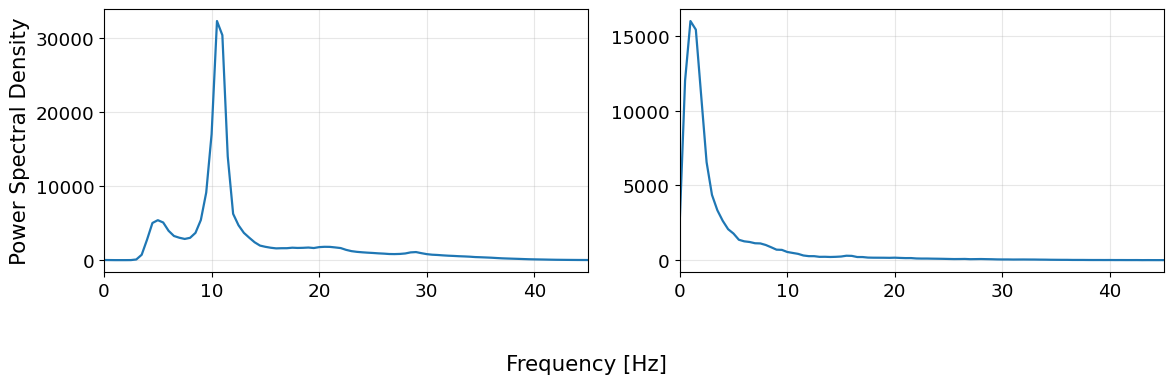

[OK] Figure saved at: Figures/Freq.pdf


In [7]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt

from scipy.signal import welch
from Model_utils.utils import get_segmented_data


# ============================================================
# 0. Configuration
# ============================================================

MI_07_SUBJECTS_TO_EXTRACT = {
    "0-7": {
        14: 4,
        12: 5,
    },
}

TDAH_DATA_FOLD = 4

FS_MI = 128
FS_TDAH = 128

NPERSEG = 256
MAX_FREQ_PLOT = 45

OUTPUT_DIR = "Figures"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ------------------------------------------------------------
# Font-size configuration
# ------------------------------------------------------------
# caption_fontsize_pt should match the approximate caption size
# used in the manuscript.
#
# figure_fontsize_pt controls axis labels and global labels.
# tick_fontsize_pt controls axis tick labels.

caption_fontsize_pt = 22

figure_fontsize_pt = 0.70 * caption_fontsize_pt
tick_fontsize_pt = 0.60 * caption_fontsize_pt

plt.rcParams.update({
    "font.size": figure_fontsize_pt,
    "axes.labelsize": figure_fontsize_pt,
    "xtick.labelsize": tick_fontsize_pt,
    "ytick.labelsize": tick_fontsize_pt,
    "legend.fontsize": figure_fontsize_pt,
    "axes.titlesize": figure_fontsize_pt,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


# ============================================================
# 1. Utilities
# ============================================================

def ensure_NCT(X):
    """
    Converts X to shape [N, C, T].

    Supported shapes:
        [N, C, T]
        [N, C, T, 1]
    """

    X = np.asarray(X, dtype=np.float32)

    if X.ndim == 3:
        return X

    if X.ndim == 4 and X.shape[-1] == 1:
        return X[..., 0]

    raise ValueError(
        f"Unsupported shape. Expected [N, C, T] or [N, C, T, 1], "
        f"but received {X.shape}."
    )


def compute_mean_psd_welch(
    X_nct,
    fs,
    nperseg=256,
):
    """
    Computes the average spectrum using Welch's method.

    Input:
        X_nct: [N, C, T]

    Output:
        freqs: [F]
        psd_mean: [F]
        psd_all: [N, C, F]

    The PSD is averaged over samples and channels.
    """

    X_nct = ensure_NCT(X_nct)

    N, C, T = X_nct.shape

    nperseg = min(nperseg, T)

    psd_all = []

    for i in range(N):

        freqs, psd = welch(
            X_nct[i],
            fs=fs,
            nperseg=nperseg,
            axis=-1,
        )
        # psd: [C, F]

        psd_all.append(psd)

    psd_all = np.asarray(psd_all)  # [N, C, F]

    psd_mean = np.nanmean(
        psd_all,
        axis=(0, 1),
    )

    return freqs, psd_mean, psd_all


# ============================================================
# 2. Load selected MI 0-7 segments
# ============================================================

def load_selected_mi_07_segments(
    base_path_mi="Data/MI",
    mi_subjects_to_extract=MI_07_SUBJECTS_TO_EXTRACT,
):
    """
    Loads only the X_test segments from MI 0-7.

    Subjects:
        sj14 fold4
        sj12 fold5
    """

    X_list = []

    for window_name, subjects_folds in mi_subjects_to_extract.items():

        if str(window_name) != "0-7":
            continue

        for subject_id, fold in subjects_folds.items():

            file_path = os.path.join(
                base_path_mi,
                str(window_name),
                f"subject_{subject_id}.npz",
            )

            if not os.path.exists(file_path):
                raise FileNotFoundError(
                    f"The MI file does not exist:\n{file_path}"
                )

            data = np.load(file_path)

            X = data["X"].astype(np.float32)

            test_key = f"fold_{fold}_test_idx"

            if test_key not in data.files:
                raise KeyError(
                    f"The key {test_key} does not exist in:\n{file_path}"
                )

            test_idx = data[test_key].astype(int)

            X_test = X[test_idx].astype(np.float32)
            X_test = ensure_NCT(X_test)

            X_list.append(X_test)

            print(
                f"[OK] MI | window={window_name} | "
                f"subject={subject_id} | fold={fold} | "
                f"X_test={X_test.shape}"
            )

            data.close()

    if len(X_list) == 0:
        raise ValueError(
            "No MI 0-7 block was loaded."
        )

    X_mi_07_selected = np.concatenate(
        X_list,
        axis=0,
    )

    print("=" * 80)
    print("Selected MI 0-7")
    print("=" * 80)
    print("X_mi_07_selected:", X_mi_07_selected.shape)

    return X_mi_07_selected


# ============================================================
# 3. Load selected TDAH fold
# ============================================================

def load_selected_tdah_segments(
    fold_to_extract=TDAH_DATA_FOLD,
    folds_path="Data/TDAH/folds.pkl",
    path_adhd="Data/TDAH/ieee/ADHD_group",
    path_control="Data/TDAH/ieee/Control_group",
):
    """
    Loads X_test from TDAH using the selected fold.

    Note:
        fold_to_extract=4 corresponds to the fifth fold
        if folds are indexed from 0.
    """

    if not os.path.exists(folds_path):
        raise FileNotFoundError(
            f"folds_path does not exist:\n{folds_path}"
        )

    with open(folds_path, "rb") as f:
        folds = pickle.load(f)

    X, y, sbjs, extra = get_segmented_data(
        path_adhd=path_adhd,
        path_control=path_control,
        apply_notch=False,
    )

    X = np.asarray(X, dtype=np.float32)
    sbjs = np.asarray(sbjs)

    train_subjects, _, test_subjects = folds[fold_to_extract]

    test_idx = np.asarray(
        [
            i for i, sbj in enumerate(sbjs)
            if sbj in test_subjects
        ],
        dtype=int,
    )

    X_test = X[test_idx].astype(np.float32)
    X_test = ensure_NCT(X_test)

    print("=" * 80)
    print("Selected TDAH")
    print("=" * 80)
    print("fold_to_extract:", fold_to_extract)
    print("X_tdah_test:", X_test.shape)
    print("Test subjects:", len(test_subjects))

    return X_test


# ============================================================
# 4. Compute average spectra
# ============================================================

X_mi_07_selected = load_selected_mi_07_segments(
    base_path_mi="Data/MI",
    mi_subjects_to_extract=MI_07_SUBJECTS_TO_EXTRACT,
)

X_tdah_selected = load_selected_tdah_segments(
    fold_to_extract=TDAH_DATA_FOLD,
)

freqs_mi, psd_mi_mean, _ = compute_mean_psd_welch(
    X_nct=X_mi_07_selected,
    fs=FS_MI,
    nperseg=NPERSEG,
)

freqs_tdah, psd_tdah_mean, _ = compute_mean_psd_welch(
    X_nct=X_tdah_selected,
    fs=FS_TDAH,
    nperseg=NPERSEG,
)


# ============================================================
# 5. Plot 1x2 figure
# ============================================================

mask_mi = freqs_mi <= MAX_FREQ_PLOT
mask_tdah = freqs_tdah <= MAX_FREQ_PLOT

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(12, 4),
    sharey=False,
)

# -----------------------------
# MI panel
# -----------------------------

axes[0].plot(
    freqs_mi[mask_mi],
    psd_mi_mean[mask_mi],
    linewidth=1.6,
)

axes[0].set_xlim(
    0,
    MAX_FREQ_PLOT,
)

axes[0].set_ylabel(
    "Power Spectral Density",
    fontsize=figure_fontsize_pt,
)

axes[0].set_xlabel("")
axes[0].set_title("")

axes[0].tick_params(
    axis="both",
    labelsize=tick_fontsize_pt,
)

axes[0].grid(
    True,
    alpha=0.3,
)

# -----------------------------
# TDAH panel
# -----------------------------

axes[1].plot(
    freqs_tdah[mask_tdah],
    psd_tdah_mean[mask_tdah],
    linewidth=1.6,
)

axes[1].set_xlim(
    0,
    MAX_FREQ_PLOT,
)

axes[1].set_ylabel("")
axes[1].set_xlabel("")
axes[1].set_title("")

axes[1].tick_params(
    axis="both",
    labelsize=tick_fontsize_pt,
)

axes[1].grid(
    True,
    alpha=0.3,
)

# -----------------------------
# Global x-axis label
# -----------------------------

fig.supxlabel(
    "Frequency [Hz]",
    y=0.03,
    fontsize=figure_fontsize_pt,
)

plt.tight_layout(
    rect=[0, 0.05, 1, 1],
)

output_path = os.path.join(
    OUTPUT_DIR,
    "Freq.pdf",
)

fig.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(f"[OK] Figure saved at: {output_path}")